In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [26]:
# Load the cleaned dataset from Week 1

file_path = "../data/processed/adult_cleaned.csv"

df = pd.read_csv(file_path)

print("Cleaned dataset loaded successfully!")
print("Dataset shape:", df.shape)

Cleaned dataset loaded successfully!
Dataset shape: (32537, 15)


In [9]:
# Display the first 5 rows

df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [10]:
# Check dataset information

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32537 entries, 0 to 32536
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32537 non-null  int64
 1   workclass       32537 non-null  str  
 2   fnlwgt          32537 non-null  int64
 3   education       32537 non-null  str  
 4   education-num   32537 non-null  int64
 5   marital-status  32537 non-null  str  
 6   occupation      32537 non-null  str  
 7   relationship    32537 non-null  str  
 8   race            32537 non-null  str  
 9   sex             32537 non-null  str  
 10  capital-gain    32537 non-null  int64
 11  capital-loss    32537 non-null  int64
 12  hours-per-week  32537 non-null  int64
 13  native-country  32537 non-null  str  
 14  income          32537 non-null  str  
dtypes: int64(6), str(9)
memory usage: 3.7 MB


Age Statistics
----------------
Minimum age: 17
Maximum age: 90
Mean age: 38.59
Median age: 37.0
Standard deviation: 13.64


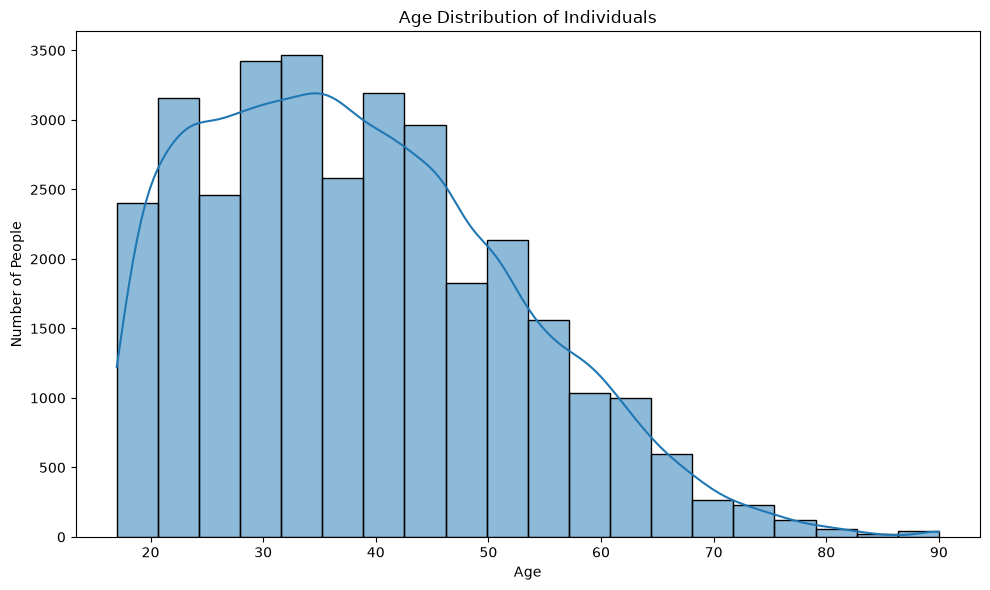

In [11]:
# Age distribution analysis

print("Age Statistics")
print("----------------")
print("Minimum age:", df["age"].min())
print("Maximum age:", df["age"].max())
print("Mean age:", round(df["age"].mean(), 2))
print("Median age:", df["age"].median())
print("Standard deviation:", round(df["age"].std(), 2))

# Plot age distribution
plt.figure(figsize=(10, 6))

sns.histplot(df["age"], bins=20, kde=True)

plt.title("Age Distribution of Individuals")
plt.xlabel("Age")
plt.ylabel("Number of People")
plt.tight_layout()
plt.show()

### Age Distribution — Analysis and Interpretation

The age distribution provides an overview of the demographic structure of the Adult Income dataset. The observations are mainly concentrated within the working-age population, while comparatively fewer observations occur at the youngest and oldest ages.

The mean and median age help describe the central tendency of the dataset, while the standard deviation indicates how widely ages are distributed around the mean. Comparing the mean and median also helps identify whether the distribution is approximately symmetric or shows some skewness.

Age is an important variable for income analysis because it can be associated with factors such as work experience, career progression, and occupation. However, age alone cannot be used to explain income differences because other variables, including education, occupation, marital status, and working hours, may also contribute.

The distribution will therefore be examined further by comparing age groups with income categories. This will help determine whether the proportion of higher-income individuals changes across different stages of the working-age population.

In [12]:
# Create age groups for deeper analysis

bins = [17, 25, 35, 45, 55, 65, 100]
labels = ["18-25", "26-35", "36-45", "46-55", "56-65", "66+"]

df["age_group"] = pd.cut(
    df["age"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

age_group_counts = df["age_group"].value_counts().sort_index()

print("Number of individuals in each age group:")
print(age_group_counts)

Number of individuals in each age group:
age_group
18-25    6400
26-35    8510
36-45    8005
46-55    5534
56-65    2931
66+      1157
Name: count, dtype: int64


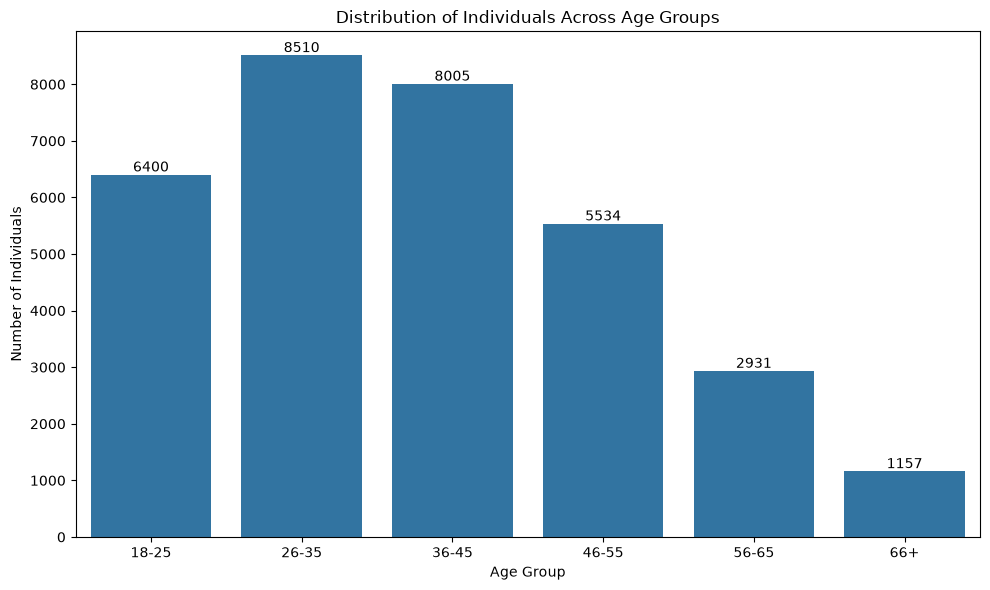

In [13]:
plt.figure(figsize=(10, 6))

ax = sns.countplot(
    data=df,
    x="age_group",
    order=labels
)

plt.title("Distribution of Individuals Across Age Groups")
plt.xlabel("Age Group")
plt.ylabel("Number of Individuals")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

### Age Group Analysis — Interpretation

Grouping individuals into age ranges makes the age distribution easier to interpret and provides a useful basis for comparing demographic groups.

The distribution shows which age ranges contain the largest number of observations in the dataset. Differences in the number of individuals across age groups indicate that the dataset is not evenly distributed across all stages of working life.

This grouping is useful for further income analysis because earning patterns may differ between younger individuals who are beginning their careers and older individuals who may have accumulated more work experience.

However, age-group comparisons should be interpreted carefully. A larger number of observations in one age group does not necessarily mean that the group has a higher probability of earning more. Therefore, the next analysis will compare the proportion of high-income individuals within each age group rather than comparing only the number of observations.

In [14]:
# Calculate income distribution within each age group

age_income_pct = pd.crosstab(
    df["age_group"],
    df["income"],
    normalize="index"
) * 100

print("Income distribution within each age group (%):")
display(age_income_pct.round(2))

Income distribution within each age group (%):


income,<=50K,>50K
age_group,,
18-25,98.22,1.78
26-35,81.30,18.70
36-45,65.37,34.63
46-55,60.14,39.86
56-65,68.51,31.49
66+,79.86,20.14


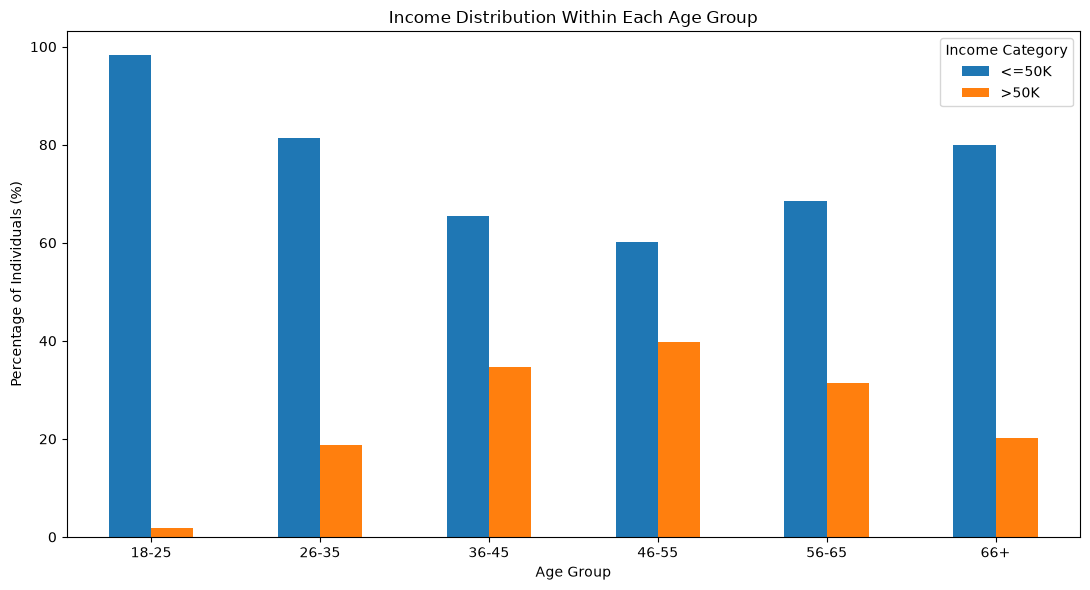

In [15]:
# Visualize income percentage by age group

age_income_pct.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title("Income Distribution Within Each Age Group")
plt.xlabel("Age Group")
plt.ylabel("Percentage of Individuals (%)")
plt.xticks(rotation=0)
plt.legend(title="Income Category")

plt.tight_layout()
plt.show()

### Age Group vs Income — Analysis and Interpretation

The percentage-based comparison shows how income categories are distributed within each age group. Using percentages rather than raw counts is important because the age groups contain different numbers of observations.

The results can be used to determine whether the proportion of individuals earning >50K changes across different age groups. If the proportion of higher-income individuals increases across some working-age groups, this may indicate an association between age and income.

One possible explanation is that individuals may accumulate work experience and progress to higher-paying positions as they become older. However, this should not be interpreted as evidence that age directly causes higher income. Education, occupation, working hours, marital status, and other factors may also contribute to the observed differences.

The age-group analysis therefore identifies a potential relationship that should be investigated alongside other variables rather than considered in isolation.

In [16]:
# Income category counts and percentages

income_counts = df["income"].value_counts()
income_percent = df["income"].value_counts(normalize=True) * 100

print("Income Counts:")
display(income_counts)

print("\nIncome Percentages:")
display(income_percent.round(2))

Income Counts:


income
<=50K    24698
>50K      7839
Name: count, dtype: int64


Income Percentages:


income
<=50K    75.91
>50K     24.09
Name: proportion, dtype: float64

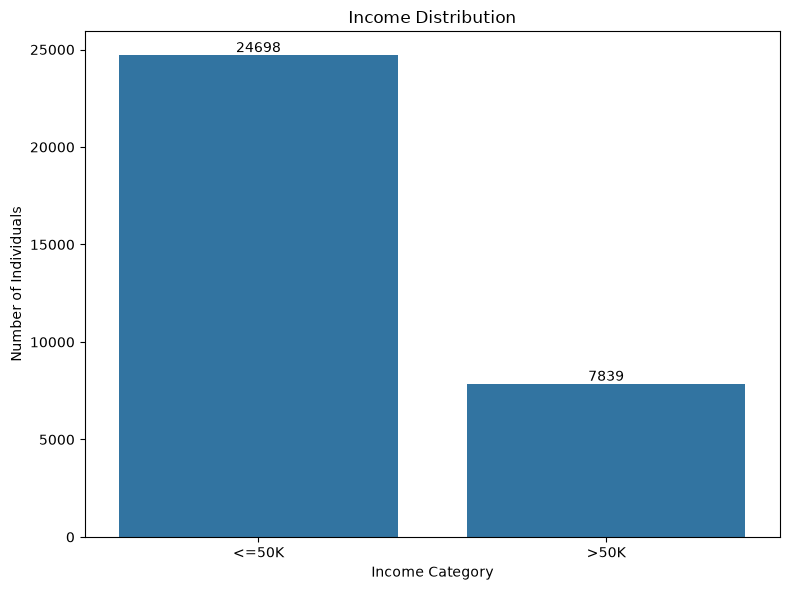

Saved: screenshots/week2/income_distribution.png


In [17]:
# Visualization 1: Income Distribution

import os

# Create the output folder if it does not already exist
os.makedirs("screenshots/week2", exist_ok=True)

income_counts = df["income"].value_counts()

plt.figure(figsize=(8, 6))

ax = sns.barplot(
    x=income_counts.index,
    y=income_counts.values
)

plt.title("Income Distribution")
plt.xlabel("Income Category")
plt.ylabel("Number of Individuals")

# Add values above the bars
for container in ax.containers:
    ax.bar_label(container, fmt="%d")

plt.tight_layout()

# Save the visualization
from pathlib import Path

output_dir = Path("../screenshots/week2")
output_dir.mkdir(parents=True, exist_ok=True)

plt.savefig(
    output_dir / "income_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved: screenshots/week2/income_distribution.png")

### Income Distribution — Analysis and Interpretation

The income variable divides individuals into two categories: <=50K and >50K. The distribution shows that the <=50K category contains considerably more observations than the >50K category.

This indicates that the target variable is imbalanced, with the lower-income category representing the majority of the dataset. This is an important characteristic to consider when performing further statistical analysis or developing a machine learning classification model.

The imbalance does not mean that the data is incorrect, and the majority class should not automatically be removed. Instead, it should be documented because it can affect how patterns are interpreted and may influence the performance of future predictive models.

If this dataset is later used for classification, accuracy alone may not provide a complete evaluation of model performance. Metrics such as precision, recall, F1-score, and the confusion matrix should also be considered, particularly for evaluating the minority >50K category.

Therefore, the income distribution provides an important foundation for the remaining exploratory analysis, where we will investigate how demographic and employment-related variables differ between the two income categories.

In [18]:
# Check education categories

education_counts = df["education"].value_counts()

print("Education categories:")
display(education_counts)

Education categories:


education
HS-grad         10494
Some-college     7282
Bachelors        5353
Masters          1722
Assoc-voc        1382
11th             1175
Assoc-acdm       1067
10th              933
7th-8th           645
Prof-school       576
9th               514
12th              433
Doctorate         413
5th-6th           332
1st-4th           166
Preschool          50
Name: count, dtype: int64

In [19]:
# Income distribution within each education level

education_income_pct = pd.crosstab(
    df["education"],
    df["income"],
    normalize="index"
) * 100

display(education_income_pct.round(2))

income,<=50K,>50K
education,,
10th,93.35,6.65
11th,94.89,5.11
12th,92.38,7.62
1st-4th,96.39,3.61
5th-6th,95.18,4.82
7th-8th,93.80,6.20
9th,94.75,5.25
Assoc-acdm,75.16,24.84
Assoc-voc,73.88,26.12


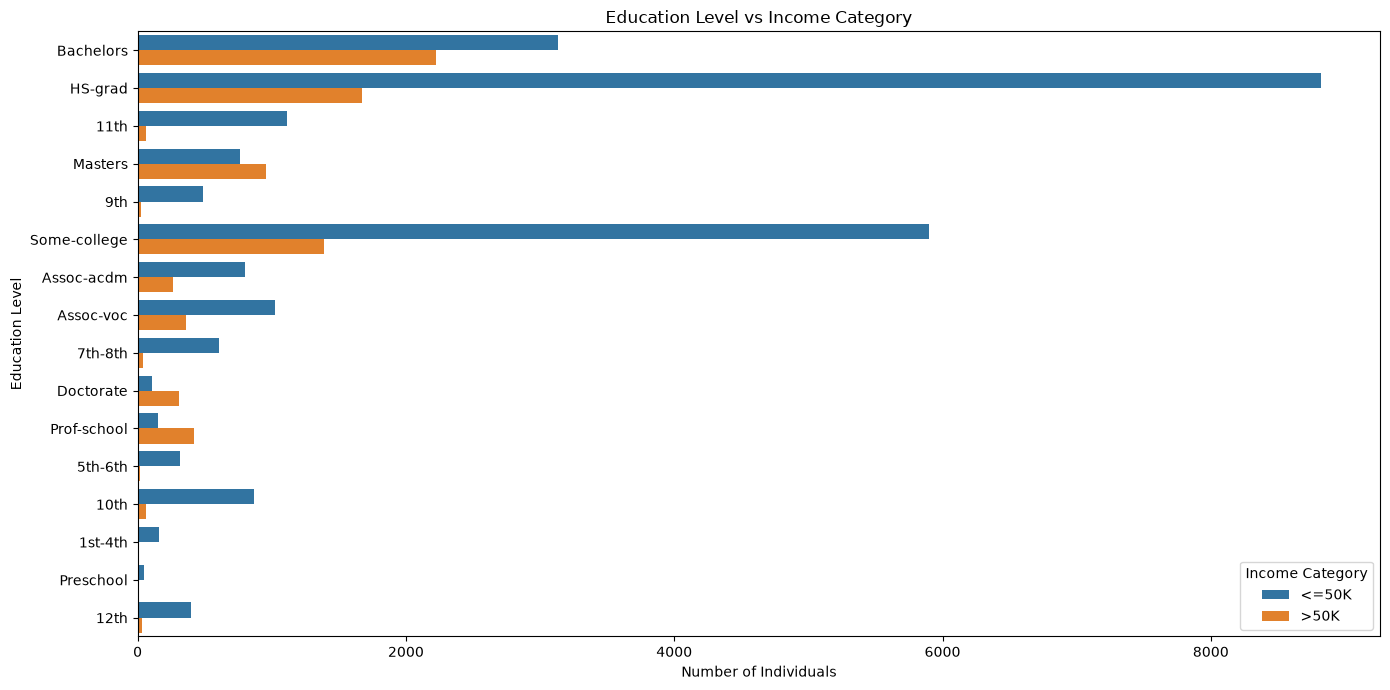

In [20]:
# Education vs Income visualization

plt.figure(figsize=(14, 7))

sns.countplot(
    data=df,
    y="education",
    hue="income"
)

plt.title("Education Level vs Income Category")
plt.xlabel("Number of Individuals")
plt.ylabel("Education Level")
plt.legend(title="Income Category")

plt.tight_layout()
plt.show()

### Education vs Income — Analysis and Interpretation

Education is one of the important socioeconomic variables in the Adult Income dataset. The visualization compares the distribution of income categories across different education levels.

The results show that income categories are not evenly distributed across education levels. Higher educational attainment generally has a greater representation of individuals earning >50K, while lower educational levels are more strongly represented in the <=50K category.

The percentage table provides a more appropriate comparison because the number of observations varies considerably between education categories. Comparing percentages helps determine the relative proportion of higher-income individuals within each education group rather than being influenced only by group size.

The observed relationship suggests that education may be associated with earning potential. Higher education can provide access to occupations requiring specialized skills or qualifications, which may offer higher salaries.

However, education should not be considered the sole explanation for income differences. Age, occupation, work experience, working hours, and other socioeconomic characteristics may also influence income. Therefore, this analysis identifies an association rather than proving a causal relationship.

In [21]:
# Working hours statistics by income category

hours_income_summary = df.groupby("income")["hours-per-week"].agg(
    ["count", "mean", "median", "min", "max", "std"]
)

display(hours_income_summary.round(2))

,count,mean,median,min,max,std
income,,,,,,
<=50K,24698,38.84,40.0,1,99,12.32
>50K,7839,45.47,40.0,1,99,11.01


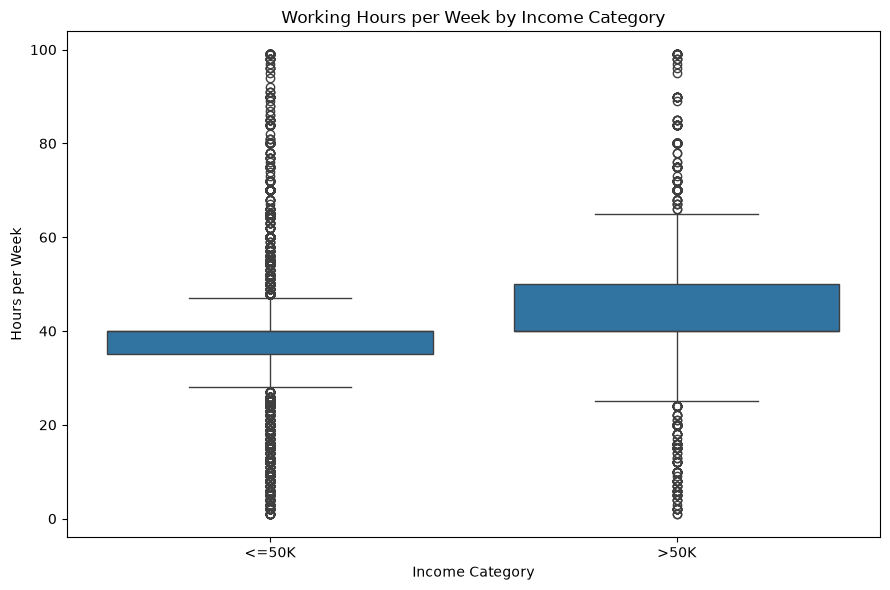

In [22]:
# Working hours vs income

plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df,
    x="income",
    y="hours-per-week"
)

plt.title("Working Hours per Week by Income Category")
plt.xlabel("Income Category")
plt.ylabel("Hours per Week")

plt.tight_layout()
plt.show()

### Working Hours vs Income — Analysis and Interpretation

The boxplot compares weekly working hours between the two income categories. The accompanying descriptive statistics provide information about the mean, median, spread, and range of working hours within each group.

If the >50K group shows a higher median number of working hours, this may indicate an association between working time and income. However, longer working hours should not automatically be interpreted as the cause of higher income because occupation, job type, education, and experience may influence both working hours and earnings.

The spread of the distributions also provides useful information about variation in working patterns. Extreme observations should be investigated rather than automatically removed because unusually high or low working hours may represent genuine cases.

This analysis helps determine whether working hours are potentially useful for explaining income differences and whether the variable should be considered in future predictive analysis.

In [23]:
# Workclass distribution

workclass_counts = df["workclass"].value_counts()

print("Workclass categories:")
display(workclass_counts)

Workclass categories:


workclass
Private             22673
Self-emp-not-inc     2540
Local-gov            2093
?                    1836
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64

In [24]:
# Income distribution within each workclass

workclass_income_pct = pd.crosstab(
    df["workclass"],
    df["income"],
    normalize="index"
) * 100

display(workclass_income_pct.round(2))

income,<=50K,>50K
workclass,,
?,89.60,10.40
Federal-gov,61.35,38.65
Local-gov,70.52,29.48
Never-worked,100.00,0.00
Private,78.12,21.88
Self-emp-inc,44.27,55.73
Self-emp-not-inc,71.50,28.50
State-gov,72.80,27.20
Without-pay,100.00,0.00


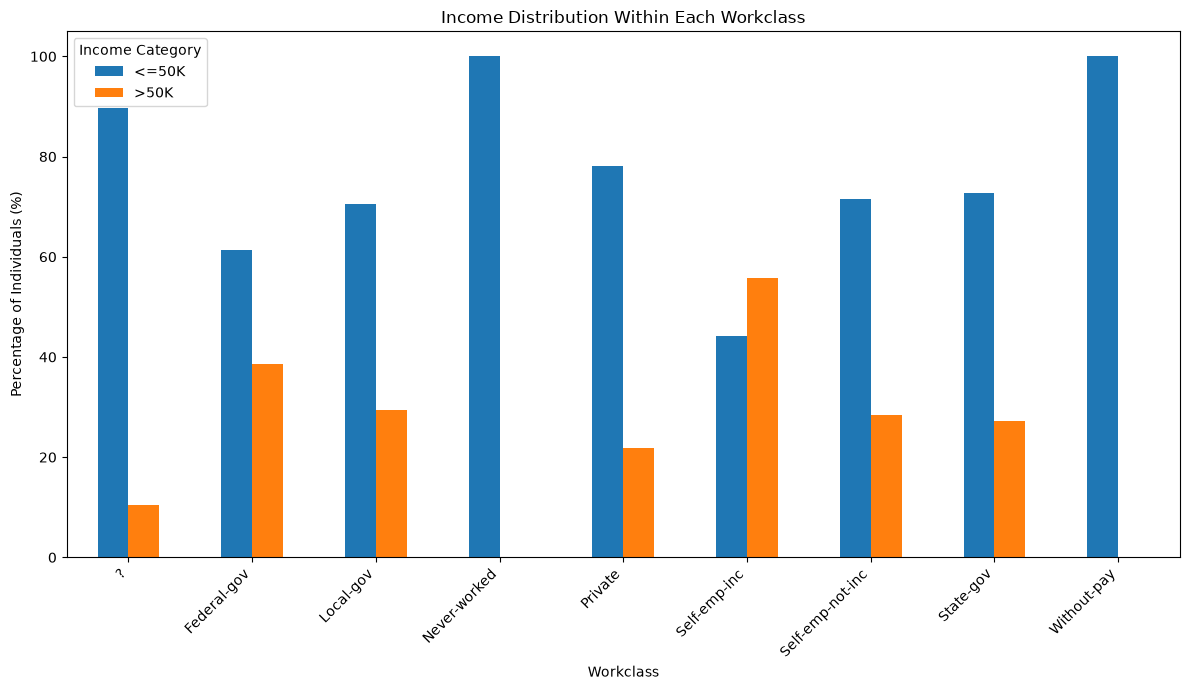

In [25]:
# Workclass vs Income

workclass_income_pct.plot(
    kind="bar",
    figsize=(12, 7)
)

plt.title("Income Distribution Within Each Workclass")
plt.xlabel("Workclass")
plt.ylabel("Percentage of Individuals (%)")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Income Category")

plt.tight_layout()
plt.show()

### Workclass vs Income — Analysis and Interpretation

The analysis compares the proportion of income categories within each workclass. Percentage-based comparison is used because the number of observations varies considerably between workclass categories.

The results help identify whether certain employment sectors have a greater proportion of individuals earning >50K. Differences between workclass categories may reflect variations in job stability, employment structure, occupation types, and access to higher-paying positions.

However, workclass should not be interpreted independently. For example, two individuals belonging to the same workclass may have substantially different incomes because of differences in education, occupation, age, and working hours.

Some workclass categories may also contain relatively few observations. Results from these smaller groups should therefore be interpreted cautiously because a small sample size can make percentages less stable.

Overall, workclass provides useful contextual information about employment structure and may contribute to explaining differences in income.

In [26]:
# Income distribution within each occupation

occupation_income_pct = pd.crosstab(
    df["occupation"],
    df["income"],
    normalize="index"
) * 100

occupation_income_pct = occupation_income_pct.round(2)

display(occupation_income_pct)

income,<=50K,>50K
occupation,,
?,89.64,10.36
Adm-clerical,86.54,13.46
Armed-Forces,88.89,11.11
Craft-repair,77.31,22.69
Exec-managerial,51.59,48.41
Farming-fishing,88.41,11.59
Handlers-cleaners,93.72,6.28
Machine-op-inspct,87.55,12.45
Other-service,95.84,4.16


In [27]:
# Rank occupations by the percentage earning >50K

high_income_by_occupation = (
    occupation_income_pct[">50K"]
    .sort_values(ascending=False)
)

display(high_income_by_occupation)

occupation
Exec-managerial      48.41
Prof-specialty       44.92
Protective-serv      32.51
Tech-support         30.53
Sales                26.93
Craft-repair         22.69
Transport-moving     20.04
Adm-clerical         13.46
Machine-op-inspct    12.45
Farming-fishing      11.59
Armed-Forces         11.11
?                    10.36
Handlers-cleaners     6.28
Other-service         4.16
Priv-house-serv       0.68
Name: >50K, dtype: float64

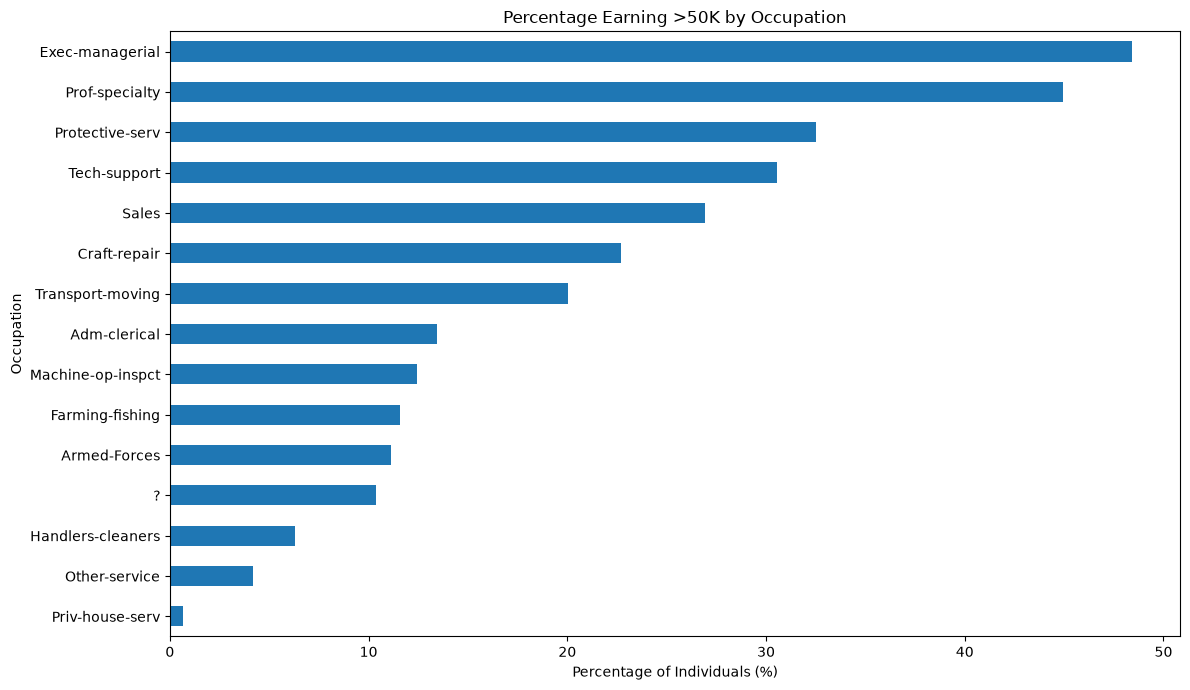

In [28]:
# Percentage of individuals earning >50K by occupation

plt.figure(figsize=(12, 7))

high_income_by_occupation.sort_values().plot(
    kind="barh"
)

plt.title("Percentage Earning >50K by Occupation")
plt.xlabel("Percentage of Individuals (%)")
plt.ylabel("Occupation")

plt.tight_layout()
plt.show()

In [29]:
# Number of observations in each occupation

occupation_counts = df["occupation"].value_counts()

occupation_summary = pd.DataFrame({
    "Total Individuals": occupation_counts,
    "Percentage >50K": high_income_by_occupation
}).sort_values("Percentage >50K", ascending=False)

display(occupation_summary)

,Total Individuals,Percentage >50K
occupation,,
Exec-managerial,4065,48.41
Prof-specialty,4136,44.92
Protective-serv,649,32.51
Tech-support,927,30.53
Sales,3650,26.93
Craft-repair,4094,22.69
Transport-moving,1597,20.04
Adm-clerical,3768,13.46
Machine-op-inspct,2000,12.45


### Occupation vs Income — Analysis and Interpretation

Occupation shows a noticeable relationship with income in the Adult Income dataset. The percentage-based analysis allows occupations to be compared fairly despite differences in the number of observations in each occupation.

The results indicate that some occupations have a substantially higher proportion of individuals earning >50K than others. This may reflect differences in required skills, education, experience, job responsibilities, and typical compensation levels across occupations.

However, the percentage of high-income individuals should be interpreted together with the number of observations in each occupation. An occupation with a very small number of observations can produce a high or low percentage that may not be representative of the broader population.

Occupation is also closely related to other variables such as education, age, workclass, and hours worked. Therefore, the observed relationship should be interpreted as an association rather than evidence that occupation alone determines income.

Overall, occupation appears to be an important feature for understanding income differences and is likely to be useful in future predictive modelling. Further analysis should examine occupation together with education, age, and other relevant variables.

In [30]:
# Marital status distribution

marital_counts = df["marital-status"].value_counts()

print("Marital status categories:")
display(marital_counts)

Marital status categories:


marital-status
Married-civ-spouse       14970
Never-married            10667
Divorced                  4441
Separated                 1025
Widowed                    993
Married-spouse-absent      418
Married-AF-spouse           23
Name: count, dtype: int64

In [31]:
# Income distribution within each marital status

marital_income_pct = pd.crosstab(
    df["marital-status"],
    df["income"],
    normalize="index"
) * 100

marital_income_pct = marital_income_pct.round(2)

display(marital_income_pct)

income,<=50K,>50K
marital-status,,
Divorced,89.57,10.43
Married-AF-spouse,56.52,43.48
Married-civ-spouse,55.31,44.69
Married-spouse-absent,91.87,8.13
Never-married,95.40,4.60
Separated,93.56,6.44
Widowed,91.44,8.56


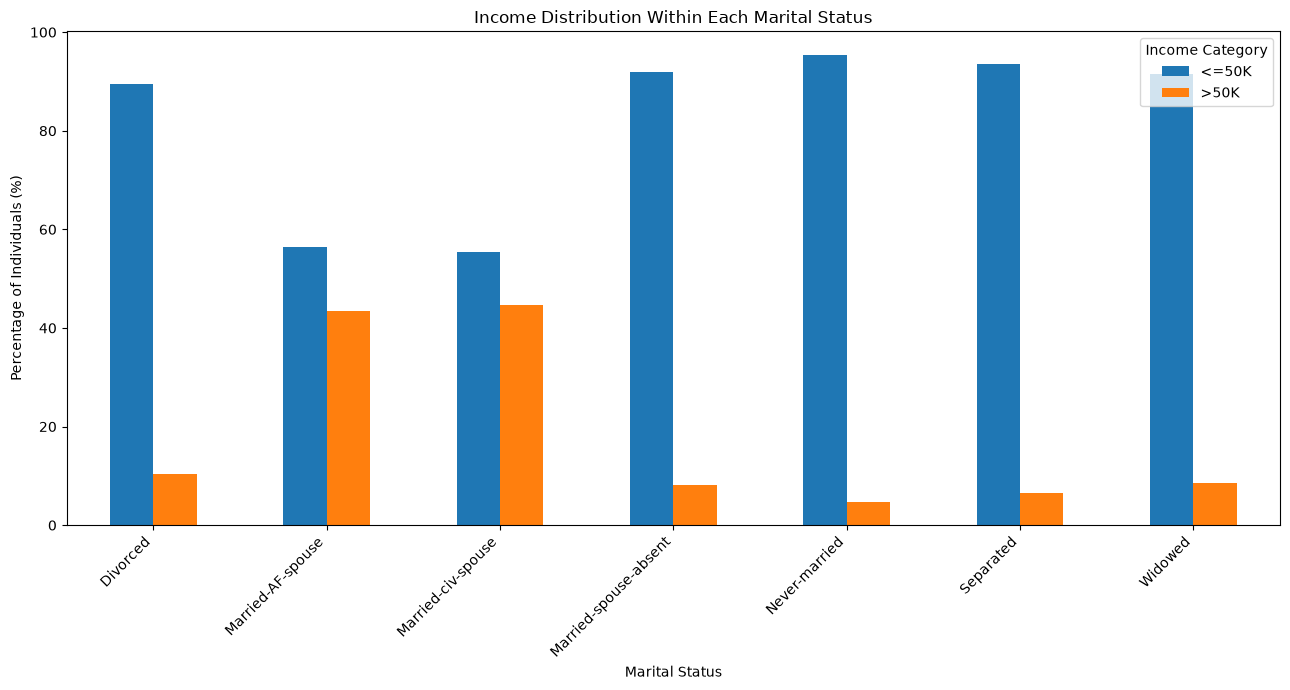

In [32]:
# Marital status vs income

marital_income_pct.plot(
    kind="bar",
    figsize=(13, 7)
)

plt.title("Income Distribution Within Each Marital Status")
plt.xlabel("Marital Status")
plt.ylabel("Percentage of Individuals (%)")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Income Category")

plt.tight_layout()
plt.show()

In [33]:
# Combine sample size and high-income percentage

high_income_by_marital = marital_income_pct[">50K"].sort_values(
    ascending=False
)

marital_summary = pd.DataFrame({
    "Total Individuals": marital_counts,
    "Percentage >50K": high_income_by_marital
}).sort_values("Percentage >50K", ascending=False)

display(marital_summary)

,Total Individuals,Percentage >50K
marital-status,,
Married-civ-spouse,14970,44.69
Married-AF-spouse,23,43.48
Divorced,4441,10.43
Widowed,993,8.56
Married-spouse-absent,418,8.13
Separated,1025,6.44
Never-married,10667,4.60


### Marital Status vs Income — Analysis and Interpretation

The analysis compares the income distribution across different marital-status categories. Percentages are used so that categories with different numbers of observations can be compared more fairly.

The results show that the proportion of individuals earning >50K varies across marital-status groups. This indicates an association between marital status and income within this dataset.

However, marital status should not be interpreted as a direct cause of income differences. The observed relationship may be influenced by other variables such as age, education, occupation, work experience, and working hours. For example, marital-status categories may have different age and employment profiles, which can contribute to the observed income differences.

The sample size of each category should also be considered when interpreting the percentages. Categories with relatively few observations may produce less stable estimates.

Therefore, marital status can be considered a potentially useful descriptive feature, but its relationship with income should be examined together with other demographic and employment variables rather than in isolation.

In [34]:
# Sex distribution

sex_counts = df["sex"].value_counts()

print("Sex categories:")
display(sex_counts)

Sex categories:


sex
Male      21775
Female    10762
Name: count, dtype: int64

In [35]:
# Income distribution within each sex category

sex_income_pct = pd.crosstab(
    df["sex"],
    df["income"],
    normalize="index"
) * 100

sex_income_pct = sex_income_pct.round(2)

display(sex_income_pct)

income,<=50K,>50K
sex,,
Female,89.04,10.96
Male,69.41,30.59


In [ ]:
# Sex vs Income

sex_income_pct.plot(
    kind="bar",
    figsize=(9, 6)
)

plt.title("Income Distribution by Sex")
plt.xlabel("Sex")
plt.ylabel("Percentage of Individuals (%)")
plt.xticks(rotation=0)
plt.legend(title="Income Category")

plt.tight_layout()
plt.show()

In [ ]:
# Combine sample size and high-income percentage

high_income_by_sex = sex_income_pct[">50K"].sort_values(
    ascending=False
)

sex_summary = pd.DataFrame({
    "Total Individuals": sex_counts,
    "Percentage >50K": high_income_by_sex
}).sort_values("Percentage >50K", ascending=False)

display(sex_summary)

,Total Individuals,Percentage >50K
sex,,
Male,21775,30.59
Female,10762,10.96


### Sex vs Income — Analysis and Interpretation

The analysis compares the income distribution across the sex categories in the dataset. Percentages are used instead of raw counts because the number of observations in each category is substantially different.

The results show a difference in the proportion of individuals earning >50K across the sex categories. This indicates an association between sex and income within this dataset.

However, the observed difference should not be interpreted as evidence that sex alone determines income. Differences in education, occupation, age, working hours, and workclass may contribute to the observed income patterns. These variables can have different distributions across the groups and may therefore influence the relationship.

The sample size of each category is also important when interpreting the results. A larger group provides more observations for estimating the overall distribution, while conclusions from smaller groups should be treated more cautiously.

This analysis identifies a demographic difference that is worth investigating further, but it does not establish causation. In future predictive analysis, this variable should be handled carefully and its relationship with other features should be considered.

In [ ]:
# Capital gain and capital loss statistics

capital_summary = df[["capital-gain", "capital-loss"]].describe()

display(capital_summary)

,capital-gain,capital-loss
count,32537.000000,32537.000000
mean,1078.443741,87.368227
std,7387.957424,403.101833
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,0.000000,0.000000
max,99999.000000,4356.000000


In [ ]:
# Check zero and non-zero capital gain/loss values

gain_zero = (df["capital-gain"] == 0).sum()
gain_nonzero = (df["capital-gain"] > 0).sum()

loss_zero = (df["capital-loss"] == 0).sum()
loss_nonzero = (df["capital-loss"] > 0).sum()

print("Capital Gain")
print("------------")
print("Zero values:", gain_zero)
print("Non-zero values:", gain_nonzero)

print("\nCapital Loss")
print("------------")
print("Zero values:", loss_zero)
print("Non-zero values:", loss_nonzero)

Capital Gain
------------
Zero values: 29825
Non-zero values: 2712

Capital Loss
------------
Zero values: 31018
Non-zero values: 1519


In [ ]:
# Average capital gain by income category

gain_income = df.groupby("income")["capital-gain"].agg(
    ["count", "mean", "median", "max"]
)

display(gain_income.round(2))

,count,mean,median,max
income,,,,
<=50K,24698,148.88,0.0,41310
>50K,7839,4007.16,0.0,99999


In [ ]:
# Average capital loss by income category

loss_income = df.groupby("income")["capital-loss"].agg(
    ["count", "mean", "median", "max"]
)

display(loss_income.round(2))

,count,mean,median,max
income,,,,
<=50K,24698,53.19,0.0,4356
>50K,7839,195.05,0.0,3683


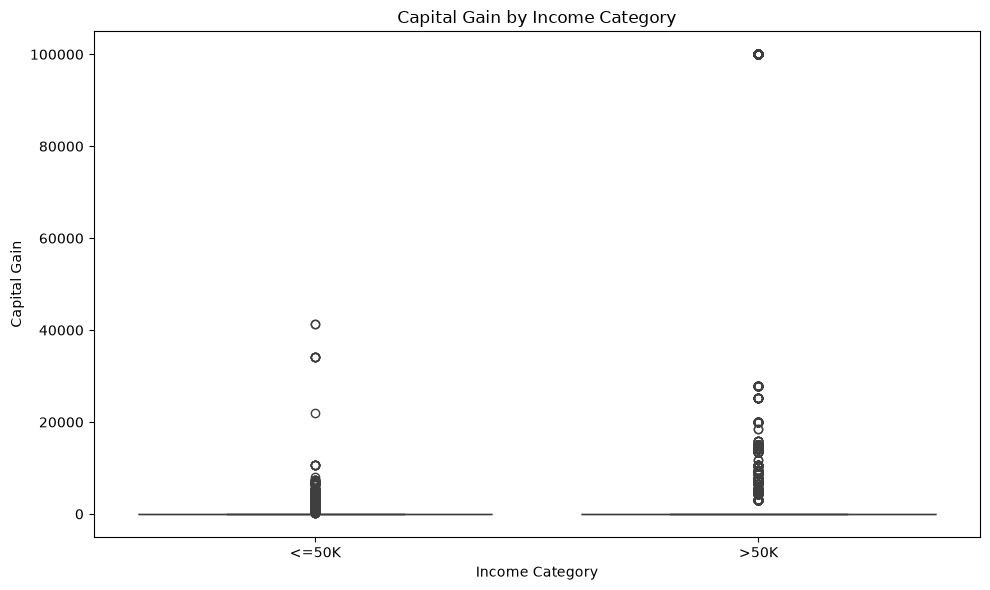

In [ ]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="income",
    y="capital-gain"
)

plt.title("Capital Gain by Income Category")
plt.xlabel("Income Category")
plt.ylabel("Capital Gain")

plt.tight_layout()
plt.show()

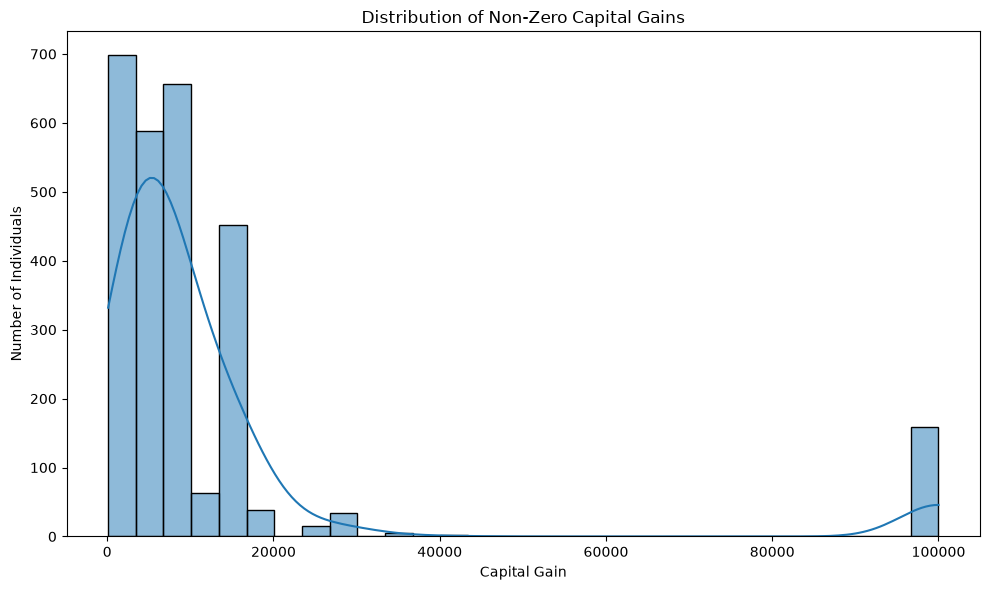

In [ ]:
# Distribution of non-zero capital gains

nonzero_gain = df[df["capital-gain"] > 0]

plt.figure(figsize=(10, 6))

sns.histplot(
    data=nonzero_gain,
    x="capital-gain",
    bins=30,
    kde=True
)

plt.title("Distribution of Non-Zero Capital Gains")
plt.xlabel("Capital Gain")
plt.ylabel("Number of Individuals")

plt.tight_layout()
plt.show()

### Capital Gain and Capital Loss — Analysis and Interpretation

Capital gain and capital loss have distributions that differ from variables such as age and working hours. A large proportion of observations have a value of zero, indicating that many individuals in the dataset do not report capital gains or capital losses.

Because of this zero-heavy distribution, the mean alone may not fully represent the typical observation. The median is also useful because it reflects the central value and is less affected by extreme observations.

The comparison between income categories can reveal whether individuals earning >50K have different capital gain or capital loss patterns from those earning <=50K. Large differences in the mean may be influenced by a relatively small number of individuals with very high capital gains.

The non-zero capital gain distribution is therefore examined separately. This provides a clearer view of the values among individuals who actually report a capital gain rather than allowing the large number of zero values to dominate the visualization.

Extreme capital gain or capital loss values should not automatically be removed as errors. They may represent genuine financial observations. Any decision to transform, cap, or otherwise preprocess these variables should be based on the purpose of the future analysis and should be documented clearly.

In [ ]:
# Select numerical columns for correlation analysis

numerical_columns = df.select_dtypes(include=np.number).columns

print("Numerical variables:")
print(list(numerical_columns))

Numerical variables:
['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']


In [ ]:
# Calculate correlation matrix

correlation_matrix = df[numerical_columns].corr()

display(correlation_matrix.round(2))

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
age,1.00,-0.08,0.04,0.08,0.06,0.07
fnlwgt,-0.08,1.00,-0.04,0.00,-0.01,-0.02
education-num,0.04,-0.04,1.00,0.12,0.08,0.15
capital-gain,0.08,0.00,0.12,1.00,-0.03,0.08
capital-loss,0.06,-0.01,0.08,-0.03,1.00,0.05
hours-per-week,0.07,-0.02,0.15,0.08,0.05,1.00


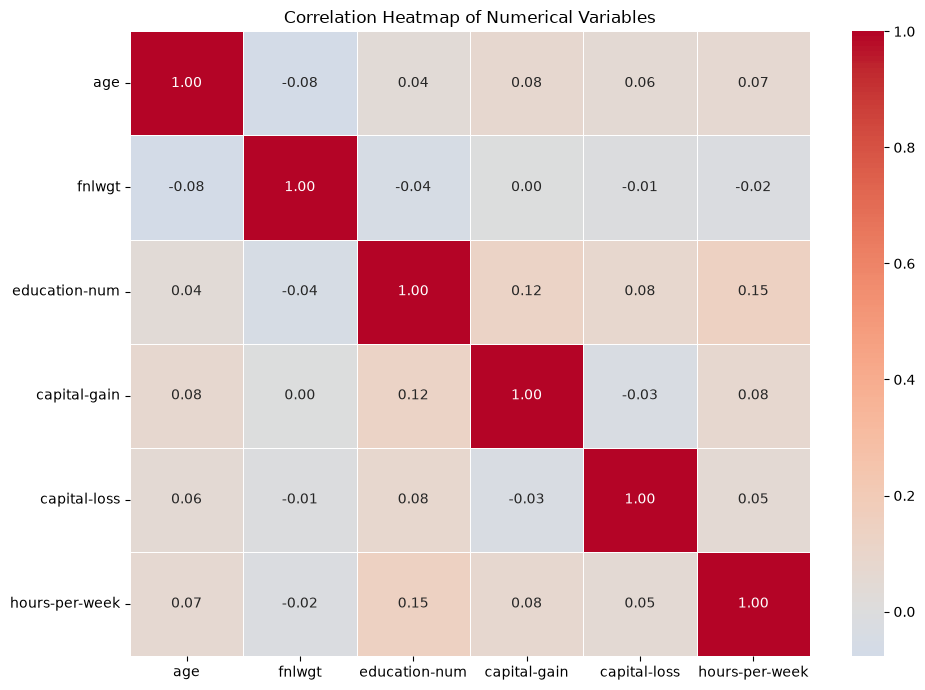

In [ ]:
# Correlation heatmap

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numerical Variables")
plt.tight_layout()
plt.show()

In [ ]:
# Identify the strongest relationships between numerical variables

corr_pairs = (
    correlation_matrix
    .where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))
    .stack()
    .sort_values(key=abs, ascending=False)
)

print("Strongest numerical correlations:")
display(corr_pairs.head(10))

Strongest numerical correlations:


education-num  hours-per-week    0.148422
               capital-gain      0.122664
               capital-loss      0.079892
capital-gain   hours-per-week    0.078408
age            capital-gain      0.077676
               fnlwgt           -0.076447
               hours-per-week    0.068515
               capital-loss      0.057745
capital-loss   hours-per-week    0.054229
fnlwgt         education-num    -0.043388
dtype: float64

### Correlation Analysis — Interpretation

The correlation matrix measures the strength and direction of linear relationships between the numerical variables in the dataset.

The heatmap makes it easier to identify variables that have relatively stronger positive or negative associations. A positive correlation means that higher values of one variable tend to be associated with higher values of another variable, while a negative correlation indicates that higher values of one variable tend to be associated with lower values of another.

The correlation analysis can help identify potentially related features and provide an initial understanding of the numerical structure of the dataset. It may also help identify variables that could be useful for future predictive modelling.

However, correlation does not imply causation. A strong correlation between two variables does not mean that one variable directly causes the other. The relationship may be influenced by other variables or underlying factors.

It is also important to note that correlation measures linear relationships. A low correlation does not necessarily mean that two variables have no relationship; they may have a non-linear relationship that is not captured by Pearson correlation.

Therefore, the correlation matrix should be treated as an exploratory tool rather than definitive evidence of causal relationships.

In [ ]:
# Create a temporary numerical representation of income

income_binary = df["income"].map({
    "<=50K": 0,
    ">50K": 1
})

numerical_income_corr = df[numerical_columns].copy()
numerical_income_corr["income_binary"] = income_binary

income_correlation = (
    numerical_income_corr.corr()["income_binary"]
    .drop("income_binary")
    .sort_values(ascending=False)
)

print("Correlation of numerical variables with income:")
display(income_correlation.round(3))

Correlation of numerical variables with income:


education-num     0.335
age               0.234
hours-per-week    0.230
capital-gain      0.223
capital-loss      0.151
fnlwgt           -0.010
Name: income_binary, dtype: float64

### Numerical Variables vs Income — Interpretation

Converting the income categories to a temporary binary representation allows the numerical variables to be compared with the target variable using correlation.

The resulting correlations indicate which numerical variables have stronger or weaker linear associations with belonging to the >50K income category.

A positive correlation indicates that higher values of a numerical variable tend to be associated with the >50K category, while a negative correlation indicates the opposite tendency.

These correlations should not be interpreted as proof that a variable determines income. Income is influenced by multiple demographic and employment characteristics, and correlation does not account for all of these factors simultaneously.

The results are therefore useful for exploratory feature understanding and for identifying variables that may deserve further investigation in future predictive modelling.

In [ ]:
# Outlier analysis using the IQR method

outlier_columns = [
    "age",
    "fnlwgt",
    "education-num",
    "capital-gain",
    "capital-loss",
    "hours-per-week"
]

outlier_summary = []

for column in outlier_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    outlier_summary.append({
        "Variable": column,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": len(outliers),
        "Outlier %": round(len(outliers) / len(df) * 100, 2)
    })

outlier_summary = pd.DataFrame(outlier_summary)

display(outlier_summary)

,Variable,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier %
0,age,28.0,48.0,20.0,-2.0,78.0,142,0.44
1,fnlwgt,117827.0,236993.0,119166.0,-60922.0,415742.0,993,3.05
2,education-num,9.0,12.0,3.0,4.5,16.5,1193,3.67
3,capital-gain,0.0,0.0,0.0,0.0,0.0,2712,8.34
4,capital-loss,0.0,0.0,0.0,0.0,0.0,1519,4.67
5,hours-per-week,40.0,45.0,5.0,32.5,52.5,9002,27.67


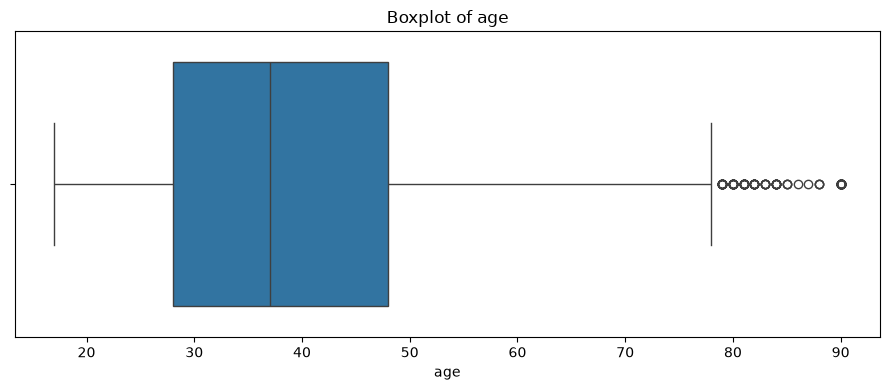

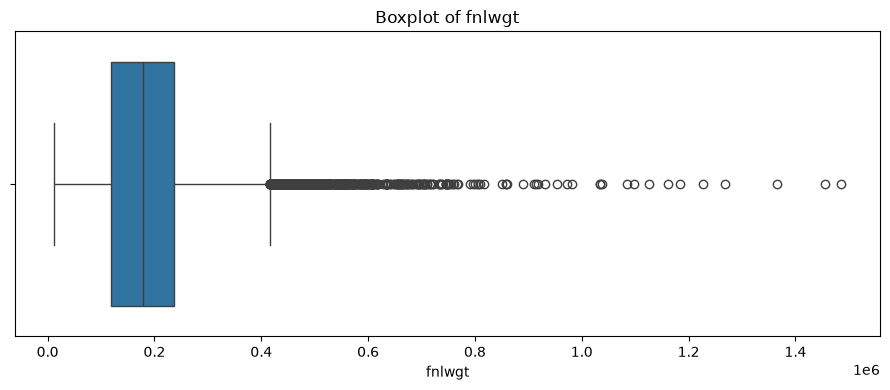

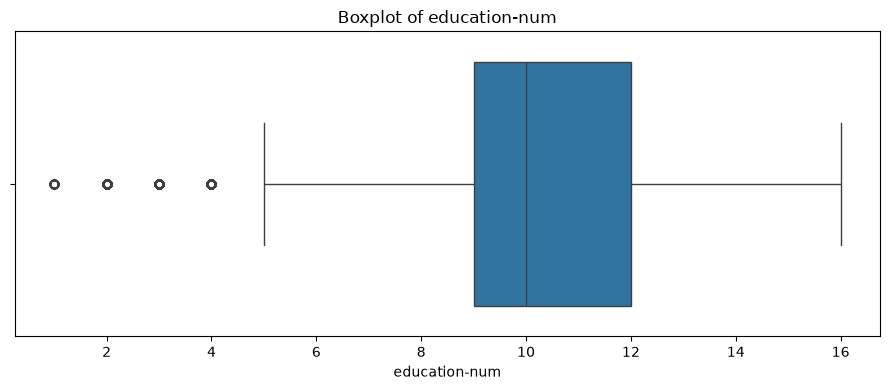

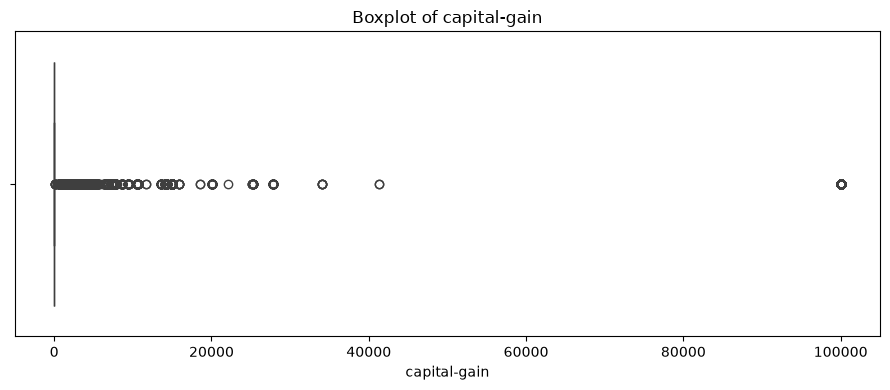

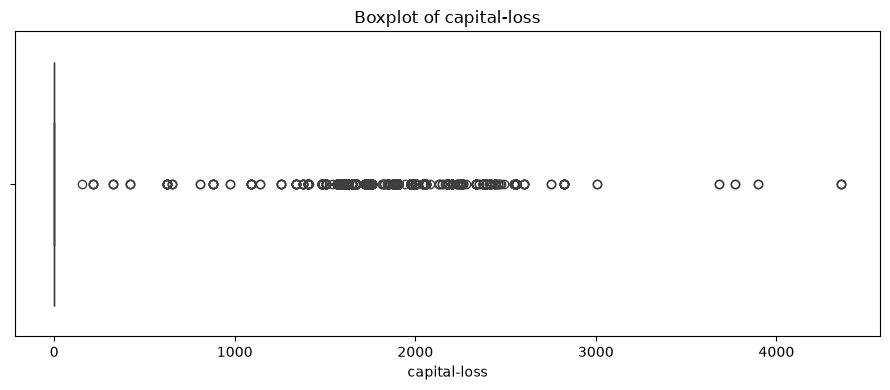

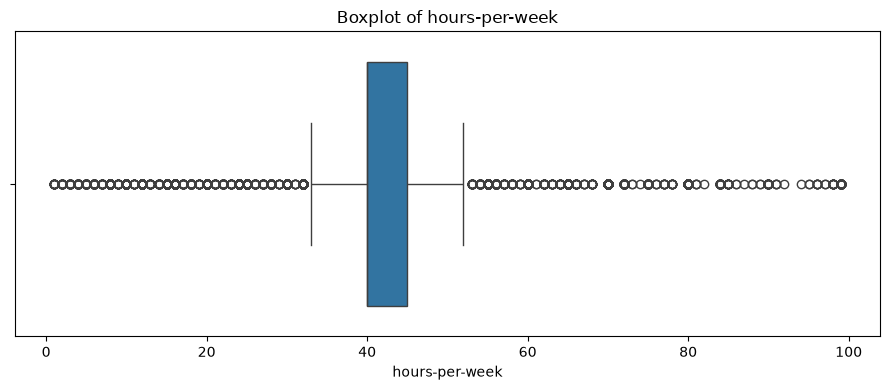

In [ ]:
# Boxplots for numerical variables

for column in outlier_columns:
    plt.figure(figsize=(9, 4))

    sns.boxplot(x=df[column])

    plt.title(f"Boxplot of {column}")
    plt.xlabel(column)

    plt.tight_layout()
    plt.show()

### Outlier Analysis — Reasoning and Interpretation

The IQR method was used to identify observations that fall substantially below or above the typical range of each numerical variable. The identified observations are statistical outliers according to the IQR rule, but they are not automatically considered incorrect data.

The presence of an outlier can have different meanings depending on the variable. For example, unusually high capital gains may represent genuine financial activity rather than an error. Similarly, unusually high working hours may represent individuals with demanding work schedules.

Therefore, removing all statistical outliers would not necessarily improve the dataset. It could instead remove legitimate observations and reduce the ability of future analysis to represent the full population.

The outlier counts and percentages provide a quantitative basis for deciding whether further investigation is necessary. Variables with a large number of extreme observations may require transformations or robust statistical methods rather than simple deletion.

For this project, the identified outliers are retained unless there is evidence that they represent data-entry errors or invalid values. This preserves potentially meaningful observations for future exploratory and predictive analysis.

If a machine learning model is developed later, the effect of extreme values can be evaluated using appropriate preprocessing techniques such as log transformation, scaling, or robust methods depending on the selected algorithm.

# Key EDA Findings

## 1. Income Distribution
The dataset contains substantially more individuals in the <=50K income category than in the >50K category. This indicates class imbalance that should be considered in future classification modelling.

## 2. Age
The age distribution is concentrated within the working-age population. Comparing age groups with income provides evidence of differences in income distribution across age ranges.

## 3. Education
Education levels show noticeable differences in income distribution. Higher educational attainment generally has a greater representation of individuals earning >50K, although education alone does not explain income.

## 4. Working Hours
Working hours differ across income categories. The relationship should be interpreted alongside occupation, education, and other employment-related variables.

## 5. Workclass
Income proportions vary across workclass categories. Categories with small sample sizes require cautious interpretation.

## 6. Occupation
Occupation shows substantial differences in the proportion of individuals earning >50K. This suggests that occupation is an important feature for understanding income differences.

## 7. Marital Status
Income distribution varies across marital-status categories. However, these differences may partly reflect differences in age, occupation, education, and other characteristics.

## 8. Sex
The income distribution differs across the sex categories in the dataset. This represents an observed association and should not be interpreted as evidence of causation.

## 9. Capital Gain and Capital Loss
Capital gain and capital loss contain many zero values and some extreme observations. These variables therefore require careful treatment rather than automatic removal of extreme values.

## 10. Correlation
Correlation analysis provides an initial view of relationships among numerical variables. However, correlation measures linear association and does not establish causation.

## Overall Conclusion

The exploratory analysis shows that income is associated with multiple demographic and employment-related characteristics. Education, occupation, age, working hours, workclass, marital status, and other variables provide different perspectives on income differences.

No single variable should be considered sufficient to explain income. The relationships observed during EDA should be investigated together in future predictive modelling.

The analysis also identified important data characteristics, including class imbalance, zero-heavy financial variables, and statistical outliers. These characteristics should be considered when designing future preprocessing and machine learning steps.

# Week 2 Conclusion

The exploratory data analysis provided a detailed understanding of the Adult Income dataset and its major demographic, educational, employment, and financial characteristics.

The analysis moved beyond simple visualizations by using descriptive statistics, percentage comparisons, group-level analysis, correlation analysis, and outlier detection.

An important principle followed throughout the analysis was that statistical patterns do not automatically imply causation. Observed relationships between variables and income may be influenced by other characteristics within the dataset.

The analysis also showed that preprocessing decisions should be made carefully. Outliers were identified using the IQR method, but they were not automatically removed because extreme observations may represent valid real-world cases.

These findings provide a strong foundation for future stages of the project, particularly feature engineering and machine learning classification. The documented class imbalance, variable relationships, and potential outlier effects will be considered when developing predictive models.

# Adult Income Dataset — Week 2 Exploratory Data Analysis

## Project Overview

This notebook performs exploratory data analysis on the cleaned Adult Income dataset.

The analysis focuses on understanding demographic, educational, employment, and financial characteristics and their relationship with income.

### Objectives

- Understand the structure and distribution of the cleaned dataset
- Analyze demographic characteristics such as age and sex
- Examine education and employment-related variables
- Investigate relationships between features and income
- Analyze numerical relationships using correlation
- Identify and evaluate potential outliers
- Document analytical decisions and their implications for future machine learning

## Table of Contents

1. Dataset Overview
2. Age Distribution Analysis
3. Age Group Analysis
4. Age Group vs Income
5. Income Distribution
6. Education vs Income
7. Working Hours vs Income
8. Workclass vs Income
9. Occupation vs Income
10. Marital Status vs Income
11. Sex vs Income
12. Capital Gain and Capital Loss
13. Correlation Analysis
14. Outlier Analysis
15. Key EDA Findings
16. Week 2 Conclusion

In [ ]:
# Final dataset quality check

print("FINAL DATASET CHECK")
print("=" * 50)

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nMissing values:")
display(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nData types:")
display(df.dtypes)

FINAL DATASET CHECK
Rows: 32537
Columns: 15

Missing values:


age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64


Duplicate rows: 0

Data types:


age               int64
workclass           str
fnlwgt            int64
education           str
education-num     int64
marital-status      str
occupation          str
relationship        str
race                str
sex                 str
capital-gain      int64
capital-loss      int64
hours-per-week    int64
native-country      str
income              str
dtype: object

## Overall Exploratory Data Analysis Findings

The exploratory data analysis revealed several important patterns in the Adult Income dataset.

### 1. Income Distribution

The dataset contains 32,537 individuals. Approximately 75.91% of the observations belong to the `<=50K` income category, while 24.09% belong to the `>50K` category. This indicates a noticeable class imbalance, with the lower-income category representing the majority of the dataset.

This imbalance should be considered in future statistical analysis and machine learning tasks because accuracy alone may not provide a complete picture of model performance.

### 2. Age and Income

The average age of individuals in the dataset is approximately 38.59 years, with a median age of 37 years. The age-group analysis shows that the proportion of individuals earning more than 50K generally increases from younger age groups toward middle age.

For example, only 1.78% of individuals in the 18–25 age group earn more than 50K, while the percentage increases to 39.86% for the 46–55 age group. The percentage decreases somewhat in older groups.

This suggests that age may have an association with income, potentially because age can indirectly represent factors such as work experience, career progression, and professional development. However, the relationship should not be interpreted as causation.

### 3. Education and Income

Education shows one of the clearest relationships with income. Lower education categories have relatively small proportions of individuals earning more than 50K, whereas advanced education categories such as Masters, Doctorate, and Prof-school have substantially higher proportions.

For example, 74.09% of individuals with a Doctorate and 73.44% of individuals with a Prof-school education belong to the >50K income category.

The correlation analysis also identifies `education-num` as the strongest positively correlated numerical variable with income, with a correlation of approximately 0.335.

This indicates that educational attainment is an important feature to consider in subsequent analysis.

### 4. Occupation and Workclass

Occupation also shows substantial differences between income groups. Executive-managerial and professional-specialty occupations have relatively high proportions of individuals earning more than 50K.

In contrast, occupations such as other-service, handlers-cleaners, and private-house-serv have much lower proportions of higher-income individuals.

Workclass shows a similar pattern. Self-employed incorporated workers have more than half of their observations in the >50K category, while private-sector workers have a smaller proportion.

These results indicate that employment characteristics may contain useful information for understanding income differences.

### 5. Marital Status and Sex

Marital status also shows noticeable differences in income distribution. Married-civil-spouse individuals have a substantially higher proportion of >50K observations compared with never-married individuals.

The sex-based analysis shows that 30.59% of male observations belong to the >50K category compared with 10.96% of female observations.

These results describe patterns present in the dataset, but they should not be interpreted as evidence that demographic characteristics directly cause income differences. Other variables such as education, occupation, work experience, and working hours may contribute to these observed differences.

### 6. Capital Gain and Capital Loss

Capital-gain and capital-loss are highly skewed variables. Most observations contain zero values.

There are 2,712 non-zero capital-gain observations and 1,519 non-zero capital-loss observations. The maximum capital-gain value is 99,999, while the maximum capital-loss value is 4,356.

The boxplots show that these variables contain extreme values. Because zero values represent the majority of observations, the mean can be strongly influenced by a relatively small number of large values.

Therefore, median, distribution, and zero-versus-non-zero comparisons are useful when interpreting these variables.

### 7. Hours per Week

Hours-per-week has a strong concentration around the typical full-time working range, particularly around 40 hours per week.

The IQR-based analysis identifies 9,002 observations as statistical outliers. However, these observations were not automatically removed because unusually low or high working hours can represent legitimate employment situations.

Removing these values without understanding their meaning could result in loss of useful information. Therefore, the outlier analysis is treated as an identification step rather than automatic deletion.

### 8. Correlation Analysis

Among the numerical variables, `education-num` has the strongest positive correlation with income at approximately 0.335, followed by age at approximately 0.234 and hours-per-week at approximately 0.230.

Capital-gain and capital-loss also show positive relationships with income, while `fnlwgt` has almost no linear correlation with income.

The correlations are relatively moderate rather than extremely strong. Therefore, income is likely influenced by multiple variables rather than one single numerical feature.

### 9. Important EDA Conclusion

Overall, the analysis indicates that income is associated with multiple demographic, educational, employment, and financial characteristics.

Education, age, occupation, workclass, marital status, capital-related variables, and working hours all show meaningful differences across income groups.

However, these observations represent associations within the dataset and should not be interpreted as causal relationships.

The findings from this EDA provide a foundation for future statistical analysis and machine learning. In particular, the class imbalance, categorical variables, skewed financial variables, and identified outliers should be considered carefully during subsequent preprocessing and model development.

# Key Insights from the Exploratory Analysis

The exploratory analysis identified several patterns that are relevant to understanding income in the dataset.

### Income imbalance
The dataset contains 32,537 observations, with 75.91% belonging to the `<=50K` category and 24.09% belonging to the `>50K` category. This imbalance is important because future classification models should not be evaluated using accuracy alone.

### Education
Education shows a strong relationship with income. Higher education categories generally contain a larger proportion of individuals earning more than 50K. The numerical `education-num` variable also has the strongest correlation with income among the numerical features examined.

### Age
Income patterns vary considerably across age groups. The proportion earning more than 50K is particularly low among younger individuals and is higher among several middle-aged groups. This may reflect differences in experience and career progression.

### Occupation
Occupation produces some of the largest differences in income distribution. Executive-managerial and professional-specialty occupations have relatively high proportions of individuals earning more than 50K, while several service-oriented occupations have much lower proportions.

### Working hours
Hours worked per week has a positive but moderate association with income. The presence of extreme working-hour observations was investigated using the IQR method rather than automatically removing them.

### Capital gain and capital loss
Capital gain and capital loss are highly skewed, with most observations equal to zero. A relatively small number of observations contain large values. These variables therefore require careful preprocessing if they are used in future modelling.

### Demographic variables
Marital status and sex show differences in income distribution within the dataset. These findings represent statistical associations and should not be interpreted as causal relationships.

### Overall observation
The analysis suggests that income is related to multiple characteristics rather than a single variable. Education, age, occupation, workclass, working hours, and financial variables all provide different information about income.

These findings will guide the feature selection, preprocessing, and modelling decisions in the next stage of the project.

# Week 2 EDA — Final Conclusion

The Week 2 analysis provided a more detailed understanding of the Adult Income dataset by combining descriptive statistics, visual analysis, group comparisons, correlation analysis, and outlier investigation.

Several meaningful patterns were identified. Education, occupation, age, workclass, working hours, and capital-related variables show different levels of association with income. At the same time, the analysis showed that no single variable is sufficient to explain income on its own.

The dataset also contains characteristics that need to be considered in later stages, including class imbalance, highly skewed capital-related variables, categorical features, and statistical outliers.

Outliers were identified using the IQR method, but they were not automatically removed. This decision was made because some extreme observations may represent genuine cases rather than incorrect data. Future modelling can evaluate whether transformations or robust preprocessing techniques are appropriate.

Overall, the EDA provides a practical foundation for the next stage of the project. The patterns and data-quality observations identified here will be used to guide feature preparation and machine learning experiments.

# Week 2 Deliverables

## Completed Work

- Loaded and validated the cleaned Adult Income dataset from Week 1.
- Performed demographic analysis using age groups.
- Compared income distribution across age groups.
- Analyzed overall income distribution and class imbalance.
- Investigated the relationship between education and income.
- Analyzed working hours across income categories.
- Investigated workclass and occupation in relation to income.
- Compared income distribution across marital-status categories.
- Compared income distribution across sex categories.
- Analyzed capital gain and capital loss distributions.
- Performed numerical correlation analysis.
- Examined correlations between numerical features and income.
- Identified statistical outliers using the IQR method.
- Evaluated whether identified outliers should be retained or removed.
- Documented analytical observations and limitations.
- Summarized findings for future machine-learning stages.

## Main Findings

The dataset contains 32,537 observations, with 75.91% belonging to the <=50K income category and 24.09% belonging to the >50K category.

Education shows a noticeable association with income. Among the numerical variables, education-num has the strongest correlation with income at approximately 0.335.

Age also shows an association with income. The proportion of individuals earning >50K increases considerably from the younger age groups toward middle age before decreasing in the oldest group.

Occupation shows substantial differences in income distribution. Exec-managerial and Prof-specialty have some of the highest proportions of individuals earning >50K.

Working hours have a moderate positive association with income, with a correlation of approximately 0.230.

Capital gain and capital loss are highly zero-heavy and contain extreme values. These variables therefore require careful consideration during future preprocessing.

The IQR analysis identified statistical outliers in several numerical variables. These observations were retained because statistical extremeness does not necessarily indicate invalid data.

## Limitations

The analysis describes relationships within the available dataset and does not establish causal relationships.

Some categorical groups contain relatively few observations, so percentages for those groups should be interpreted cautiously.

The income variable is imbalanced, which should be considered when evaluating future classification models.

Capital gain and capital loss are highly skewed and may require transformation or other preprocessing techniques in later stages.

## Next Stage

The findings from this exploratory analysis will be used to guide feature preparation and machine-learning model development in the next stage of the project.

# Report Visualizations

The following visualizations represent the most important findings from the Week 2 exploratory analysis. They were selected based on their relevance to income distribution, feature relationships, and data-quality considerations.

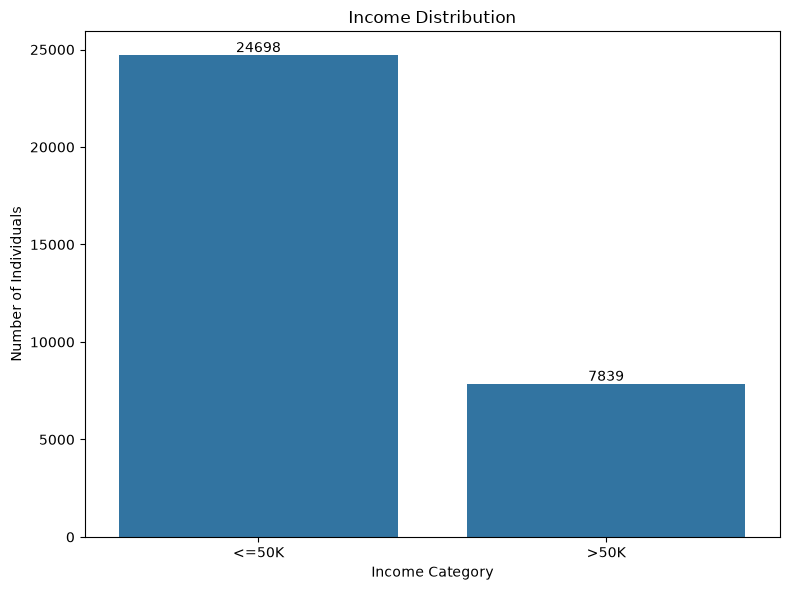

In [7]:
# Report Visualization 1: Income Distribution

income_counts = df["income"].value_counts()

plt.figure(figsize=(8, 6))

ax = sns.barplot(
    x=income_counts.index,
    y=income_counts.values
)

plt.title("Income Distribution")
plt.xlabel("Income Category")
plt.ylabel("Number of Individuals")

# Add values above the bars
for container in ax.containers:
    ax.bar_label(container, fmt="%d")

plt.tight_layout()
plt.show()

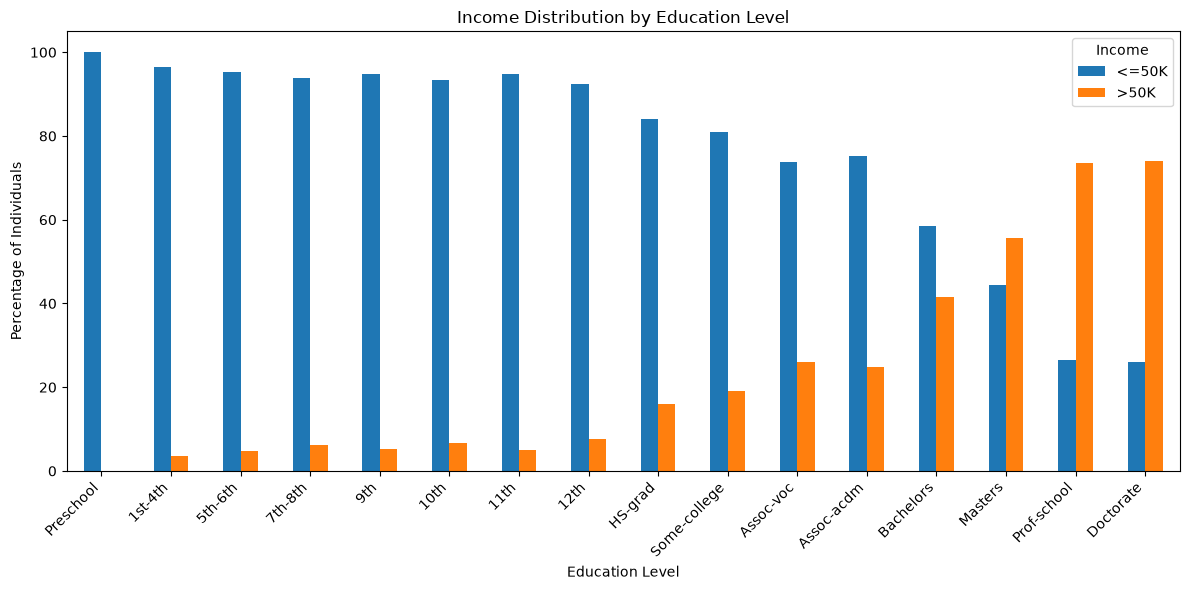

In [8]:
# Report Visualization 2: Education vs Income

education_income = pd.crosstab(
    df["education"],
    df["income"],
    normalize="index"
) * 100

# Keep education categories in a readable order
education_order = [
    "Preschool",
    "1st-4th",
    "5th-6th",
    "7th-8th",
    "9th",
    "10th",
    "11th",
    "12th",
    "HS-grad",
    "Some-college",
    "Assoc-voc",
    "Assoc-acdm",
    "Bachelors",
    "Masters",
    "Prof-school",
    "Doctorate"
]

education_income = education_income.reindex(
    [x for x in education_order if x in education_income.index]
)

ax = education_income.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Income Distribution by Education Level")
plt.xlabel("Education Level")
plt.ylabel("Percentage of Individuals")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Income")
plt.tight_layout()
plt.show()

### Insight — Education and Income

Education shows one of the clearest relationships with income in the dataset. Lower education categories generally have a much larger proportion of individuals earning <=50K, while advanced education categories have substantially higher proportions earning >50K.

For example, the >50K proportion is 41.49% for individuals with a Bachelor's degree, 55.69% for those with a Master's degree, 73.44% for Professional School, and 74.09% for Doctorate.

The numerical `education-num` variable also has the strongest correlation with the binary income variable among the numerical features examined, with a correlation of approximately 0.335.

However, this should be interpreted as an association rather than proof that education directly causes higher income. Other factors such as occupation, age, work experience, and workclass may also contribute to the observed pattern.

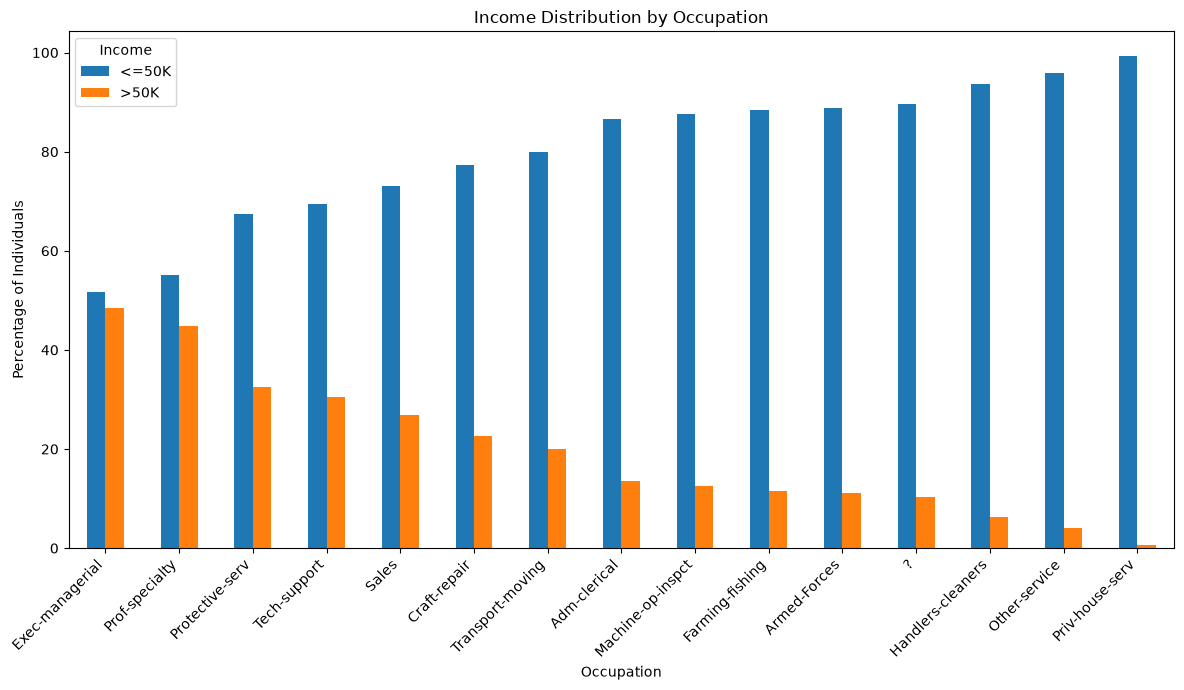

In [9]:
# Report Visualization 3: Occupation vs Income

occupation_income = pd.crosstab(
    df["occupation"],
    df["income"],
    normalize="index"
) * 100

# Sort occupations by the percentage earning >50K
occupation_income = occupation_income.sort_values(
    by=">50K",
    ascending=False
)

ax = occupation_income.plot(
    kind="bar",
    figsize=(12, 7)
)

plt.title("Income Distribution by Occupation")
plt.xlabel("Occupation")
plt.ylabel("Percentage of Individuals")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Income")
plt.tight_layout()
plt.show()

### Insight — Occupation and Income

Occupation shows substantial differences in income distribution. The proportion of individuals earning >50K is highest in Exec-managerial and Prof-specialty occupations, at 48.41% and 44.92% respectively.

Protective-serv and Tech-support also show relatively higher proportions of >50K earners, at 32.51% and 30.53%. In contrast, Other-service and Priv-house-serv have much lower proportions, at 4.16% and 0.68%.

This suggests that occupation is an important feature for understanding income differences in this dataset. However, the results should not be interpreted as a causal effect of occupation alone because occupation is related to other characteristics such as education, age, workclass, and experience.

The occupation category also contains an unknown-value group represented by `?`. These records were retained during the EDA because the purpose of this stage is to understand the dataset before making further modelling decisions.

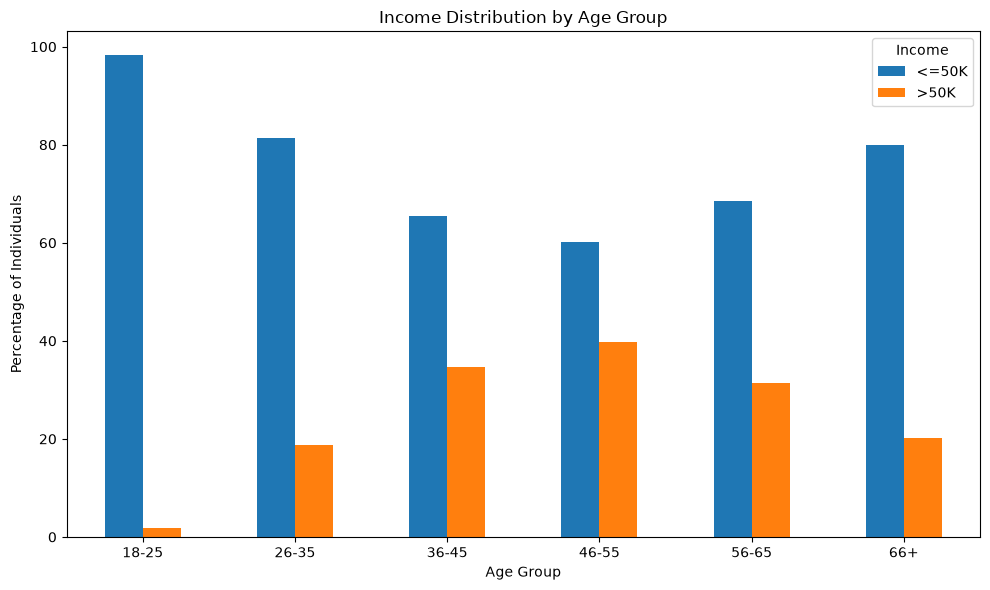

In [10]:
# Report Visualization 4: Age Group vs Income

age_bins = [17, 25, 35, 45, 55, 65, 100]
age_labels = ["18-25", "26-35", "36-45", "46-55", "56-65", "66+"]

df["age_group"] = pd.cut(
    df["age"],
    bins=age_bins,
    labels=age_labels,
    include_lowest=True
)

age_income = pd.crosstab(
    df["age_group"],
    df["income"],
    normalize="index"
) * 100

ax = age_income.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Income Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Percentage of Individuals")
plt.xticks(rotation=0)
plt.legend(title="Income")
plt.tight_layout()
plt.show()

### Insight — Age and Income

The income distribution changes noticeably across age groups. Only 1.78% of individuals in the 18–25 group earn >50K, while the proportion increases to 18.70% for 26–35, 34.63% for 36–45, and 39.86% for 46–55.

The proportion then decreases to 31.49% for 56–65 and 20.14% for individuals aged 66 or above.

This pattern suggests that age is associated with income in the dataset, with middle-aged groups showing a higher proportion of >50K earners. One possible explanation is that age may indirectly represent factors such as accumulated work experience and career progression.

However, age alone cannot explain income differences. Education, occupation, workclass, and other socioeconomic characteristics may also contribute to the observed pattern. Therefore, the relationship should be treated as an association rather than a causal conclusion.

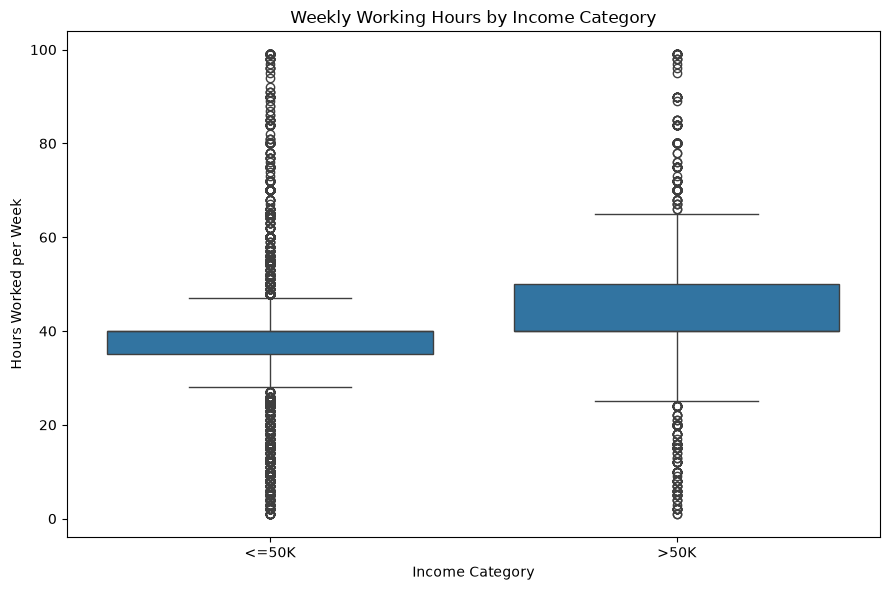

In [11]:
# Report Visualization 5: Hours-per-Week vs Income

plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df,
    x="income",
    y="hours-per-week"
)

plt.title("Weekly Working Hours by Income Category")
plt.xlabel("Income Category")
plt.ylabel("Hours Worked per Week")

plt.tight_layout()
plt.show()

### Insight — Working Hours and Income

The distribution of working hours differs between the two income categories. Individuals earning >50K generally show a higher distribution of weekly working hours compared with individuals earning <=50K.

The numerical analysis found a positive correlation of approximately 0.230 between hours-per-week and the binary income variable. This indicates a moderate positive association, meaning that higher working hours tend to be associated with a higher likelihood of belonging to the >50K category in this dataset.

However, the relationship is not strong enough to use working hours as an independent explanation for income. The boxplot also shows considerable overlap between the two income groups, indicating that people working similar numbers of hours can still belong to different income categories.

Other factors such as education, occupation, age, and workclass are likely to contribute to these differences. Therefore, working hours should be considered as one feature among several rather than a standalone predictor.



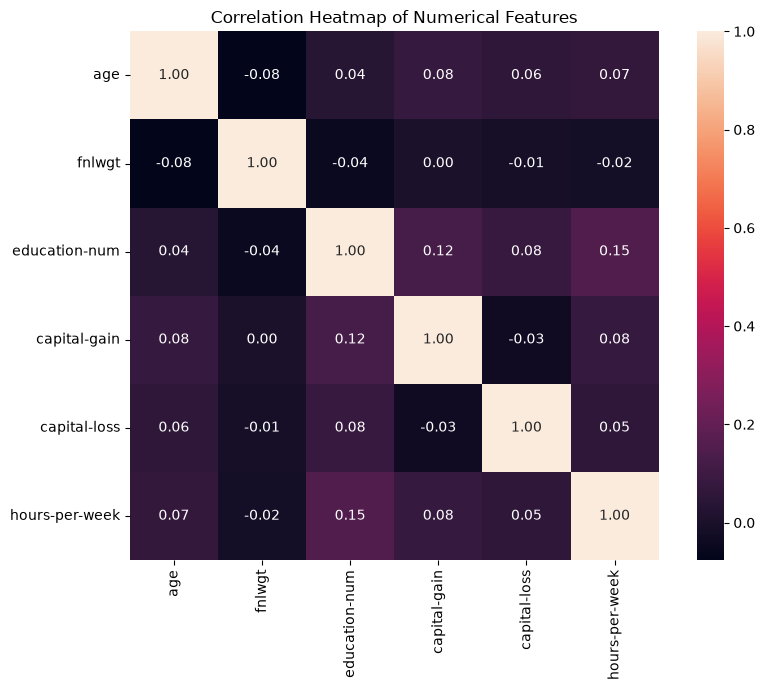

In [12]:
# Report Visualization 6: Numerical Feature Correlation Heatmap

numerical_cols = [
    "age",
    "fnlwgt",
    "education-num",
    "capital-gain",
    "capital-loss",
    "hours-per-week"
]

correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(9, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    square=True
)

plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()


### Insight — Numerical Feature Correlations

The correlation heatmap shows that most numerical variables have relatively weak linear relationships with one another.

Among the examined numerical features, education-num has a moderate positive relationship with hours-per-week and capital-gain, while most other pairwise correlations are relatively small.

The weak correlation between many features suggests that the numerical variables capture different aspects of the observations rather than being strongly redundant with one another.

Correlation measures only linear association and does not capture all possible relationships between variables. Therefore, these results should be considered alongside the categorical analysis and visualizations.

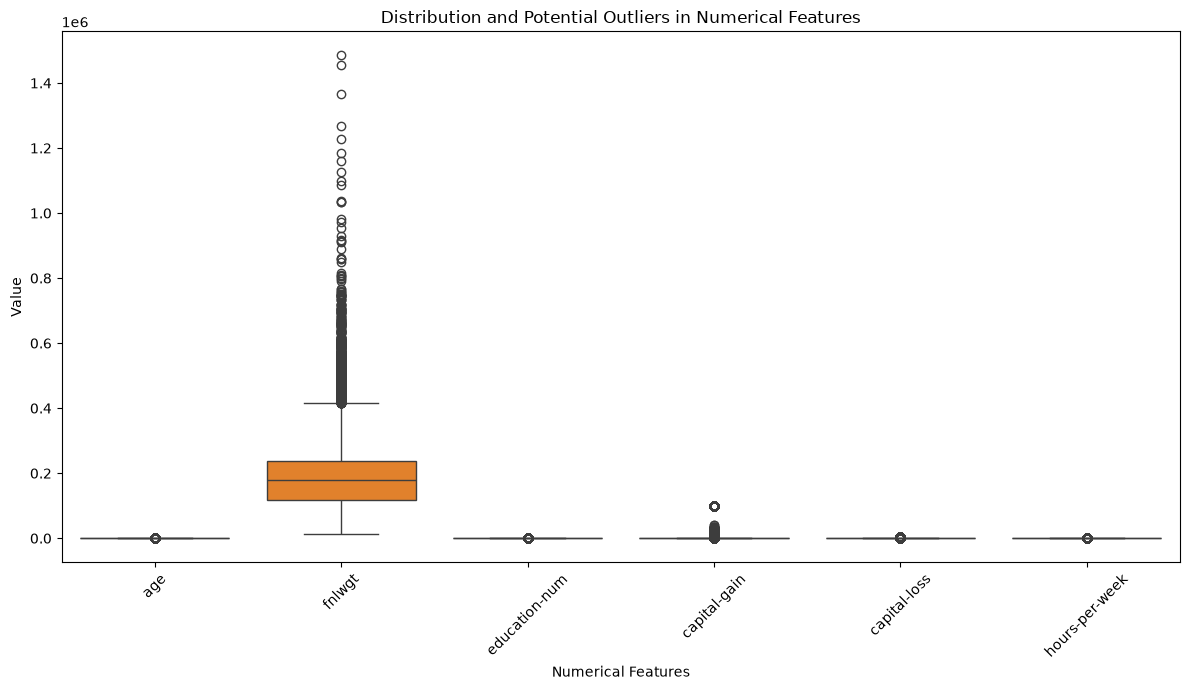

In [13]:
# Report Visualization 7: Outlier Analysis

outlier_cols = [
    "age",
    "fnlwgt",
    "education-num",
    "capital-gain",
    "capital-loss",
    "hours-per-week"
]

plt.figure(figsize=(12, 7))

sns.boxplot(data=df[outlier_cols])

plt.title("Distribution and Potential Outliers in Numerical Features")
plt.xlabel("Numerical Features")
plt.ylabel("Value")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Insight — Outlier Analysis

The IQR method identified potential statistical outliers in several numerical variables.

The highest proportion was observed in `hours-per-week`, where approximately 27.67% of observations were identified as statistical outliers using the IQR rule. Capital-gain and capital-loss also showed notable proportions of observations outside their IQR boundaries.

These observations were not automatically removed. An IQR-based outlier is statistically unusual relative to the distribution, but it is not necessarily an incorrect observation. For example, unusually high working hours or capital gains may represent legitimate individuals in the dataset.

Therefore, the outlier analysis was used to identify observations that may require attention rather than treating every statistical outlier as an error.

For future machine-learning stages, possible approaches include retaining the observations, applying suitable transformations to highly skewed variables, or testing robust modelling techniques. The appropriate approach should be determined based on model performance and the purpose of the analysis.

In [5]:
# Step 30: Education vs Income Analysis

education_income = pd.crosstab(
    df["education"],
    df["income"],
    normalize="index"
) * 100

education_income = education_income.round(2)

education_income

income,<=50K,>50K
education,,
10th,93.35,6.65
11th,94.89,5.11
12th,92.38,7.62
1st-4th,96.39,3.61
5th-6th,95.18,4.82
7th-8th,93.80,6.20
9th,94.75,5.25
Assoc-acdm,75.16,24.84
Assoc-voc,73.88,26.12


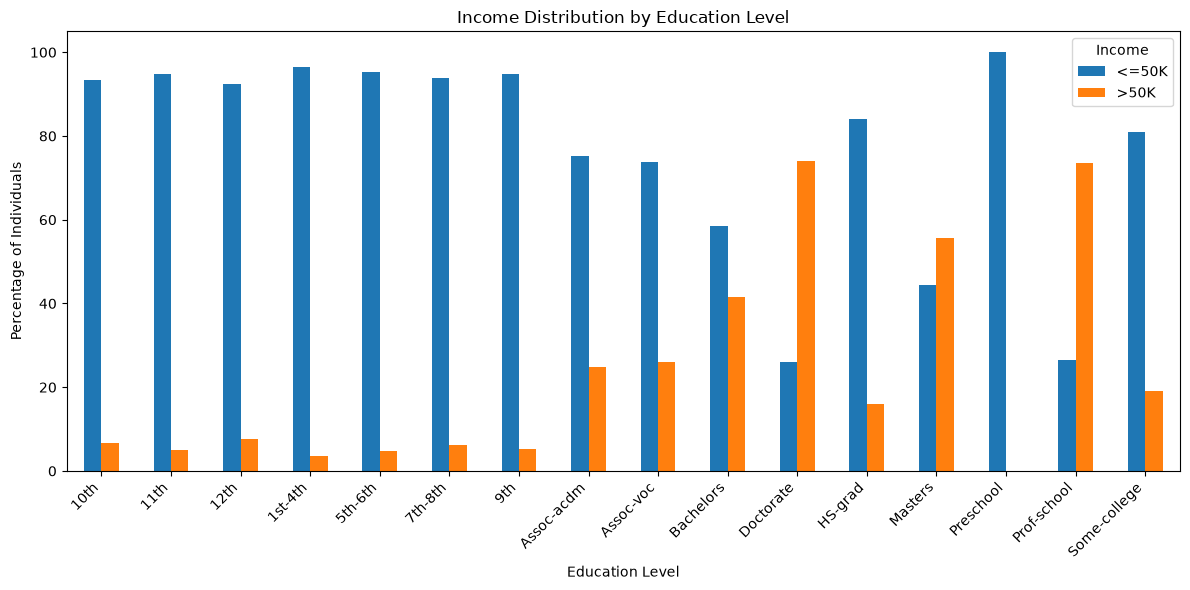

In [6]:
# Step 31: Education vs Income Visualization

education_income.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Income Distribution by Education Level")
plt.xlabel("Education Level")
plt.ylabel("Percentage of Individuals")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Income")
plt.tight_layout()
plt.show()

In [7]:
# Step 32: Save Education vs Income Visualization

from pathlib import Path

output_dir = Path("../screenshots/week2")
output_dir.mkdir(parents=True, exist_ok=True)

plt.savefig(
    output_dir / "education_vs_income.png",
    dpi=300,
    bbox_inches="tight"
)

print("Education vs Income graph saved successfully!")

Education vs Income graph saved successfully!


<Figure size 640x480 with 0 Axes>

## Education and Income Relationship

The analysis shows a clear relationship between education level and income.

Higher educational qualifications generally have a larger proportion of individuals earning more than 50K. Doctorate and Prof-school categories show particularly high proportions of individuals in the >50K income group.

Lower education categories such as 10th, 11th, 12th, and 1st-4th have a much larger proportion of individuals earning <=50K.

This suggests that education level is an important variable to consider when studying income differences. However, education alone does not determine income, as other factors such as occupation, workclass, age, and working hours may also contribute.

In [8]:
# Step 34: Occupation vs Income Analysis

occupation_income = pd.crosstab(
    df["occupation"],
    df["income"],
    normalize="index"
) * 100

occupation_income = occupation_income.round(2)

occupation_income

income,<=50K,>50K
occupation,,
?,89.64,10.36
Adm-clerical,86.54,13.46
Armed-Forces,88.89,11.11
Craft-repair,77.31,22.69
Exec-managerial,51.59,48.41
Farming-fishing,88.41,11.59
Handlers-cleaners,93.72,6.28
Machine-op-inspct,87.55,12.45
Other-service,95.84,4.16


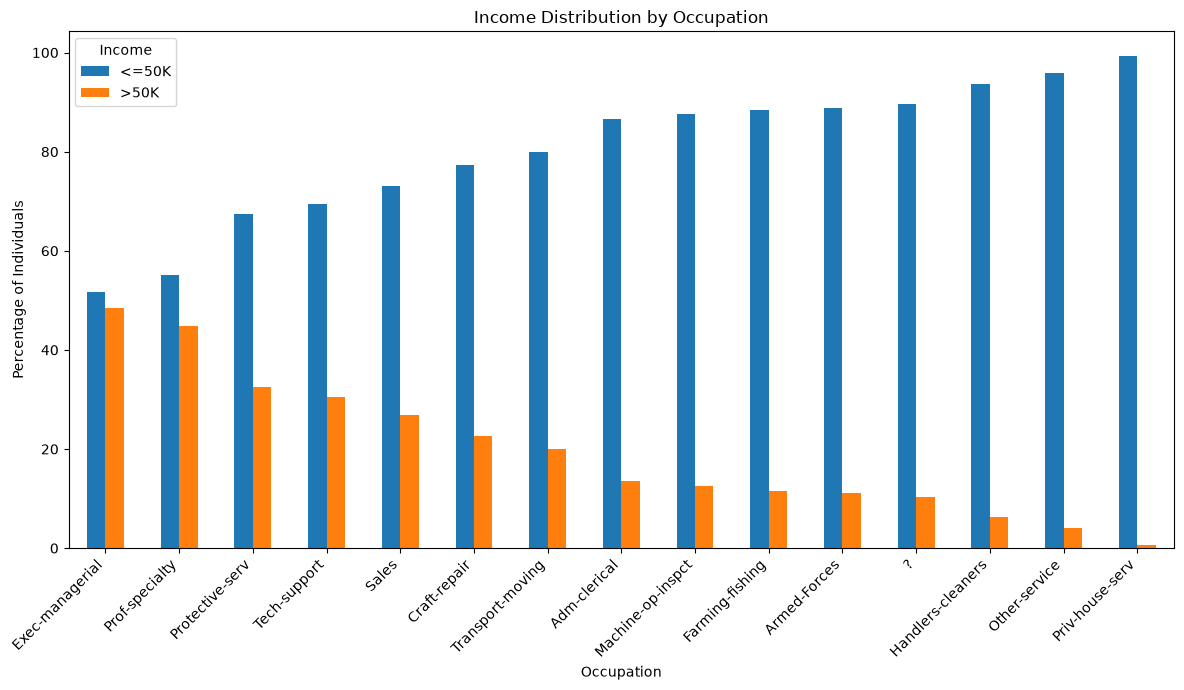

In [9]:
# Step 35: Occupation vs Income Visualization

occupation_income = occupation_income.sort_values(
    by=">50K",
    ascending=False
)

occupation_income.plot(
    kind="bar",
    figsize=(12, 7)
)

plt.title("Income Distribution by Occupation")
plt.xlabel("Occupation")
plt.ylabel("Percentage of Individuals")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Income")
plt.tight_layout()
plt.show()

In [10]:
# Step 36: Save Occupation vs Income Visualization

from pathlib import Path

output_dir = Path("../screenshots/week2")
output_dir.mkdir(parents=True, exist_ok=True)

plt.savefig(
    output_dir / "occupation_vs_income.png",
    dpi=300,
    bbox_inches="tight"
)

print("Occupation vs Income graph saved successfully!")

Occupation vs Income graph saved successfully!


<Figure size 640x480 with 0 Axes>

## Occupation and Income Relationship

The analysis shows substantial variation in income distribution across occupations.

Exec-managerial has the highest proportion of individuals earning >50K at 48.41%, followed by Prof-specialty at 44.92%. Protective-serv and Tech-support also show relatively higher proportions of >50K earners.

In contrast, occupations such as Other-service and Priv-house-serv have much smaller proportions of individuals earning >50K.

This suggests that occupation is an important variable when examining income differences in the dataset. However, occupation should not be considered independently because it can be related to education, workclass, age, and other characteristics.

The `?` category represents unknown occupation values. These observations were retained during the exploratory stage rather than being removed without further investigation.

In [11]:
# Step 38: Age Group vs Income Analysis

age_bins = [17, 25, 35, 45, 55, 65, 100]
age_labels = ["18-25", "26-35", "36-45", "46-55", "56-65", "66+"]

df["age_group"] = pd.cut(
    df["age"],
    bins=age_bins,
    labels=age_labels,
    include_lowest=True
)

age_income = pd.crosstab(
    df["age_group"],
    df["income"],
    normalize="index"
) * 100

age_income = age_income.round(2)

age_income

income,<=50K,>50K
age_group,,
18-25,98.22,1.78
26-35,81.30,18.70
36-45,65.37,34.63
46-55,60.14,39.86
56-65,68.51,31.49
66+,79.86,20.14


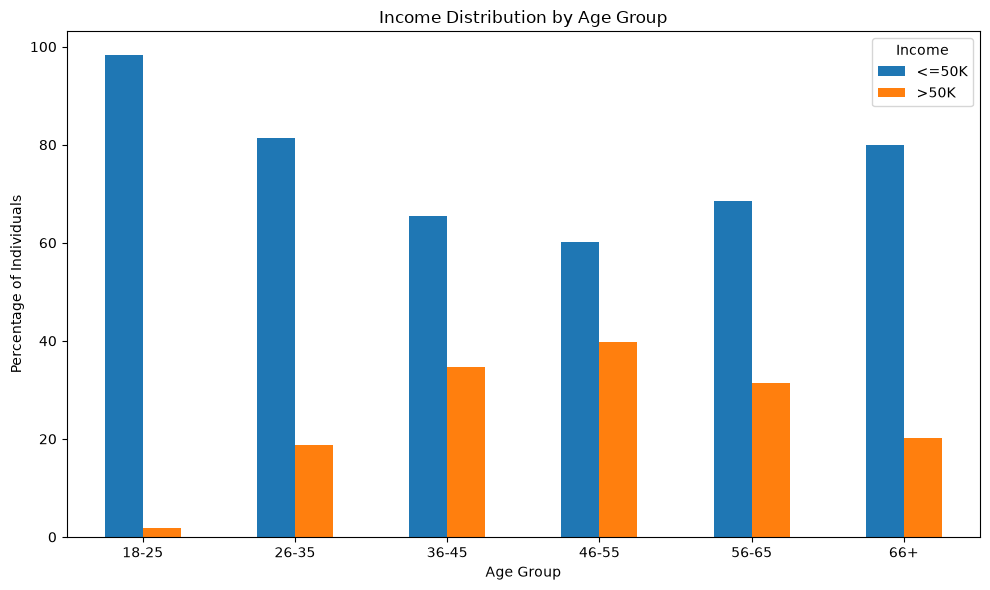

In [12]:
# Step 39: Age Group vs Income Visualization

age_income.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Income Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Percentage of Individuals")
plt.xticks(rotation=0)
plt.legend(title="Income")
plt.tight_layout()
plt.show()

In [13]:
# Step 40: Save Age Group vs Income Visualization

from pathlib import Path

output_dir = Path("../screenshots/week2")
output_dir.mkdir(parents=True, exist_ok=True)

plt.savefig(
    output_dir / "age_group_vs_income.png",
    dpi=300,
    bbox_inches="tight"
)

print("Age Group vs Income graph saved successfully!")

Age Group vs Income graph saved successfully!


<Figure size 640x480 with 0 Axes>

## Age and Income Relationship

The analysis shows that income distribution changes considerably across age groups.

The 18-25 age group has the lowest proportion of individuals earning >50K, at only 1.78%. The proportion increases across the 26-35, 36-45, and 46-55 groups, reaching 39.86% for the 46-55 age group.

After age 55, the proportion of >50K earners decreases to 31.49% for the 56-65 group and 20.14% for the 66+ group.

This pattern suggests that income tends to increase with age during the main working years, but the relationship is not simply linear. Other factors such as education, occupation, workclass, and working hours may also influence income.

The age-group analysis therefore provides useful evidence that age is associated with income differences in this dataset, while not being sufficient by itself to explain income.

In [14]:
# Step 42: Workclass vs Income Analysis

workclass_income = pd.crosstab(
    df["workclass"],
    df["income"],
    normalize="index"
) * 100

workclass_income = workclass_income.round(2)

workclass_income

income,<=50K,>50K
workclass,,
?,89.60,10.40
Federal-gov,61.35,38.65
Local-gov,70.52,29.48
Never-worked,100.00,0.00
Private,78.12,21.88
Self-emp-inc,44.27,55.73
Self-emp-not-inc,71.50,28.50
State-gov,72.80,27.20
Without-pay,100.00,0.00


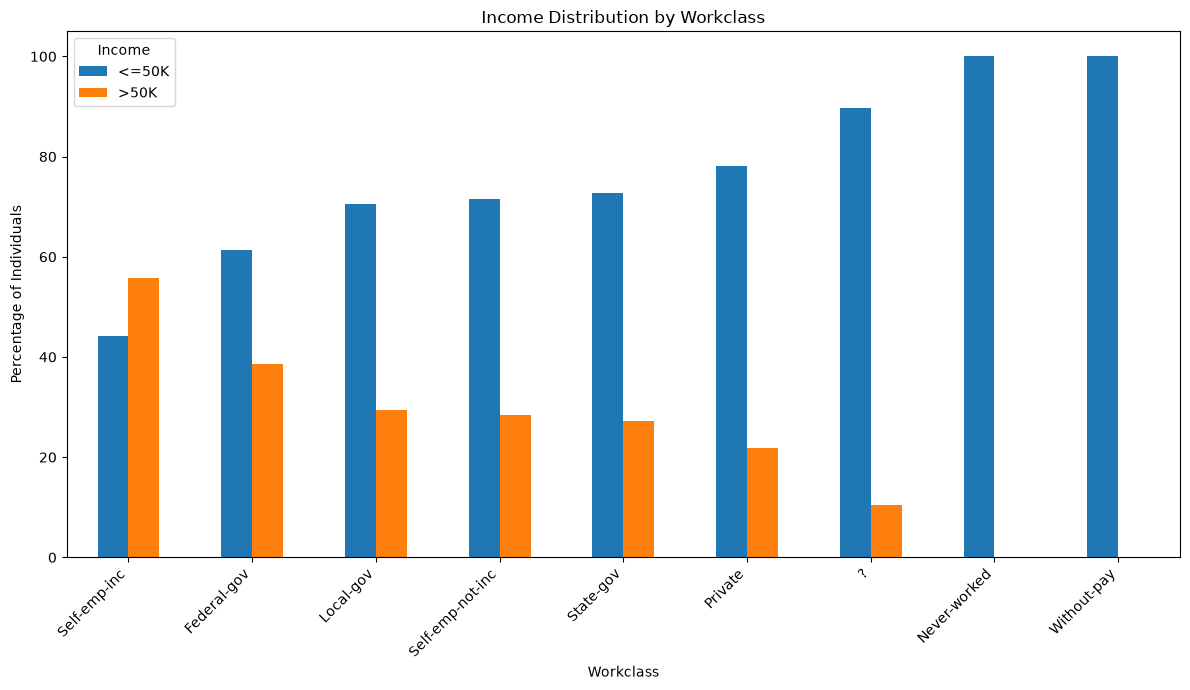

Workclass vs Income graph saved successfully!


In [15]:
# Workclass vs Income Visualization

workclass_income = workclass_income.sort_values(
    by=">50K",
    ascending=False
)

ax = workclass_income.plot(
    kind="bar",
    figsize=(12, 7)
)

plt.title("Income Distribution by Workclass")
plt.xlabel("Workclass")
plt.ylabel("Percentage of Individuals")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Income")
plt.tight_layout()

output_dir = Path("../screenshots/week2")
output_dir.mkdir(parents=True, exist_ok=True)

plt.savefig(
    output_dir / "workclass_vs_income.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Workclass vs Income graph saved successfully!")

## Workclass and Income Relationship

The workclass analysis shows noticeable differences in income distribution across employment categories.

Self-emp-inc has the highest proportion of individuals earning >50K, followed by Federal-gov and Local-gov. Private-sector workers form the largest group in the dataset, but their proportion of >50K earners is lower than the Self-emp-inc category.

The unknown `?` workclass category has a relatively low proportion of >50K earners. Categories such as Never-worked and Without-pay contain very few observations, so their percentages should be interpreted cautiously.

Overall, the results suggest that employment type is associated with income differences. However, workclass alone cannot explain income because occupation, education, age, and other variables also contribute to the observed differences.

In [16]:
# Step 43: Marital Status vs Income Analysis

marital_income = pd.crosstab(
    df["marital-status"],
    df["income"],
    normalize="index"
) * 100

marital_income = marital_income.round(2)

marital_income

income,<=50K,>50K
marital-status,,
Divorced,89.57,10.43
Married-AF-spouse,56.52,43.48
Married-civ-spouse,55.31,44.69
Married-spouse-absent,91.87,8.13
Never-married,95.40,4.60
Separated,93.56,6.44
Widowed,91.44,8.56


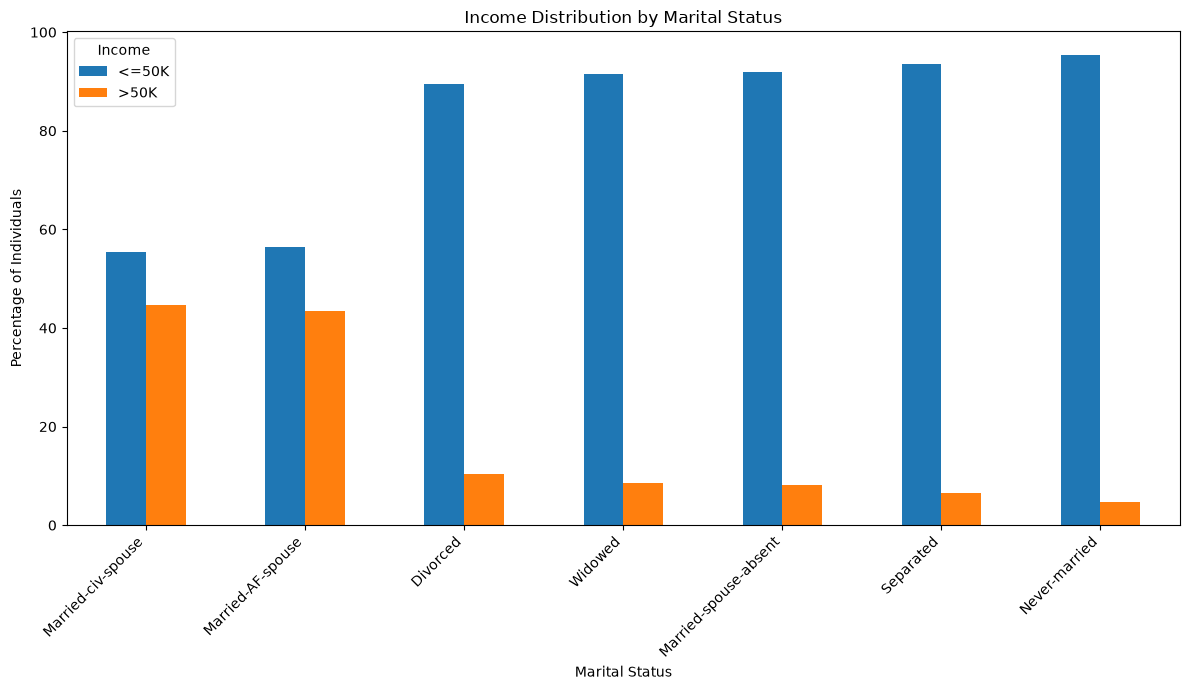

Marital Status vs Income graph saved successfully!


In [17]:
# Marital Status vs Income Visualization

marital_income = marital_income.sort_values(
    by=">50K",
    ascending=False
)

ax = marital_income.plot(
    kind="bar",
    figsize=(12, 7)
)

plt.title("Income Distribution by Marital Status")
plt.xlabel("Marital Status")
plt.ylabel("Percentage of Individuals")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Income")
plt.tight_layout()

output_dir = Path("../screenshots/week2")
output_dir.mkdir(parents=True, exist_ok=True)

plt.savefig(
    output_dir / "marital_status_vs_income.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Marital Status vs Income graph saved successfully!")

## Marital Status and Income Relationship

The analysis shows clear differences in income distribution across marital-status categories.

Married-civ-spouse has a relatively high proportion of individuals earning >50K, while Never-married has a much lower proportion. The married categories therefore show a different income pattern compared with categories such as Divorced, Separated, and Widowed.

The Married-AF-spouse category has very few observations, so its percentage should not be treated as representative of the wider population.

These results indicate an association between marital status and income in the dataset. However, this should not be interpreted as a causal relationship. Marital status may be related to other factors such as age, occupation, education, and household circumstances.

In [18]:
# Step 44: Sex vs Income Analysis

sex_income = pd.crosstab(
    df["sex"],
    df["income"],
    normalize="index"
) * 100

sex_income = sex_income.round(2)

sex_income

income,<=50K,>50K
sex,,
Female,89.04,10.96
Male,69.41,30.59


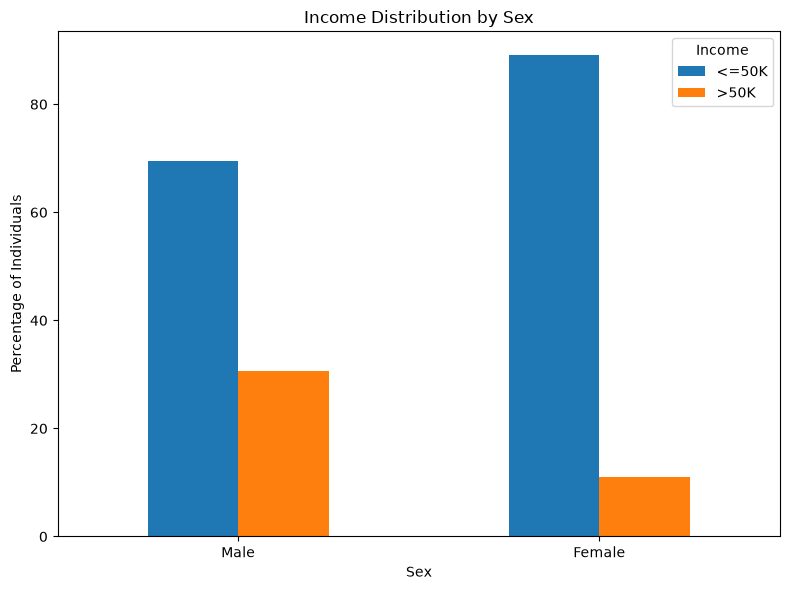

Sex vs Income graph saved successfully!


In [19]:
# Sex vs Income Visualization

sex_income = sex_income.sort_values(
    by=">50K",
    ascending=False
)

ax = sex_income.plot(
    kind="bar",
    figsize=(8, 6)
)

plt.title("Income Distribution by Sex")
plt.xlabel("Sex")
plt.ylabel("Percentage of Individuals")
plt.xticks(rotation=0)
plt.legend(title="Income")
plt.tight_layout()

output_dir = Path("../screenshots/week2")
output_dir.mkdir(parents=True, exist_ok=True)

plt.savefig(
    output_dir / "sex_vs_income.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Sex vs Income graph saved successfully!")

## Sex and Income Relationship

The analysis shows a noticeable difference in income distribution between the two sex categories in the dataset.

The proportion of individuals earning >50K is higher for males than females in this dataset. At the same time, the majority of individuals in both categories belong to the <=50K income group.

This result shows an association between sex and income within the dataset, but it should not be interpreted as a causal relationship. Differences in other variables such as occupation, education, workclass, age, and working hours may also contribute to the observed pattern.

The analysis is therefore useful for identifying patterns in the dataset, while avoiding conclusions that go beyond what the available data can establish.

In [20]:
# Step 45: Hours per Week vs Income Analysis

hours_income = df.groupby("income")["hours-per-week"].agg(
    ["count", "mean", "median", "min", "max", "std"]
).round(2)

hours_income

,count,mean,median,min,max,std
income,,,,,,
<=50K,24698,38.84,40.0,1,99,12.32
>50K,7839,45.47,40.0,1,99,11.01


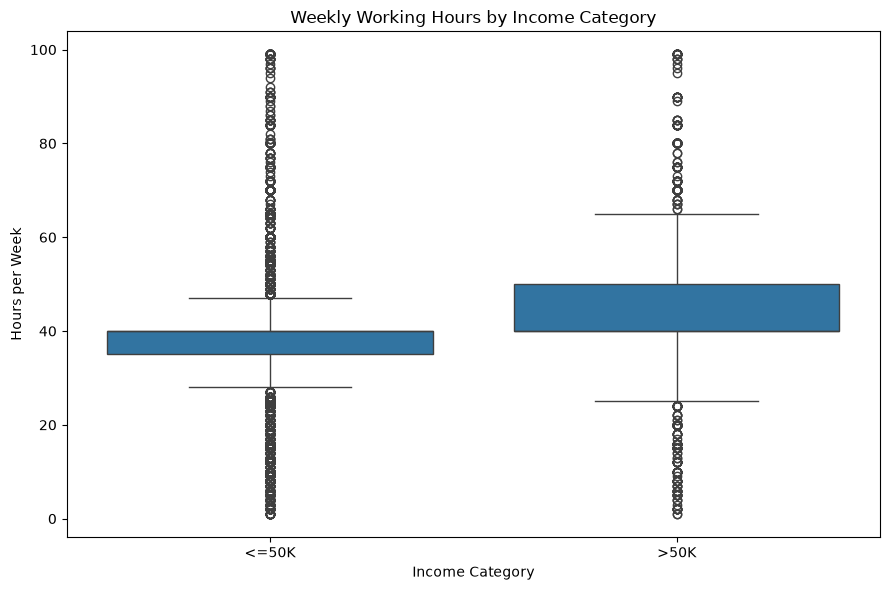

Hours per Week vs Income graph saved successfully!


In [21]:
# Hours per Week vs Income Visualization

plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df,
    x="income",
    y="hours-per-week"
)

plt.title("Weekly Working Hours by Income Category")
plt.xlabel("Income Category")
plt.ylabel("Hours per Week")
plt.tight_layout()

output_dir = Path("../screenshots/week2")
output_dir.mkdir(parents=True, exist_ok=True)

plt.savefig(
    output_dir / "hours_per_week_vs_income.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Hours per Week vs Income graph saved successfully!")

## Working Hours and Income Relationship

The analysis shows a difference in the distribution of weekly working hours between the two income categories.

Individuals earning >50K generally tend to have higher weekly working hours compared with individuals earning <=50K. The box plot also shows that there is considerable overlap between the two groups.

The correlation analysis found a positive correlation of approximately 0.230 between `hours-per-week` and the binary income variable. This indicates a moderate association rather than a strong relationship.

Therefore, working hours may provide useful information for income prediction, but working longer hours alone does not determine whether an individual belongs to the >50K income category.

In [22]:
# Step 46: Capital Gain vs Income Analysis

capital_gain_income = df.groupby("income")["capital-gain"].agg(
    ["count", "mean", "median", "min", "max"]
).round(2)

capital_gain_income

,count,mean,median,min,max
income,,,,,
<=50K,24698,148.88,0.0,0,41310
>50K,7839,4007.16,0.0,0,99999


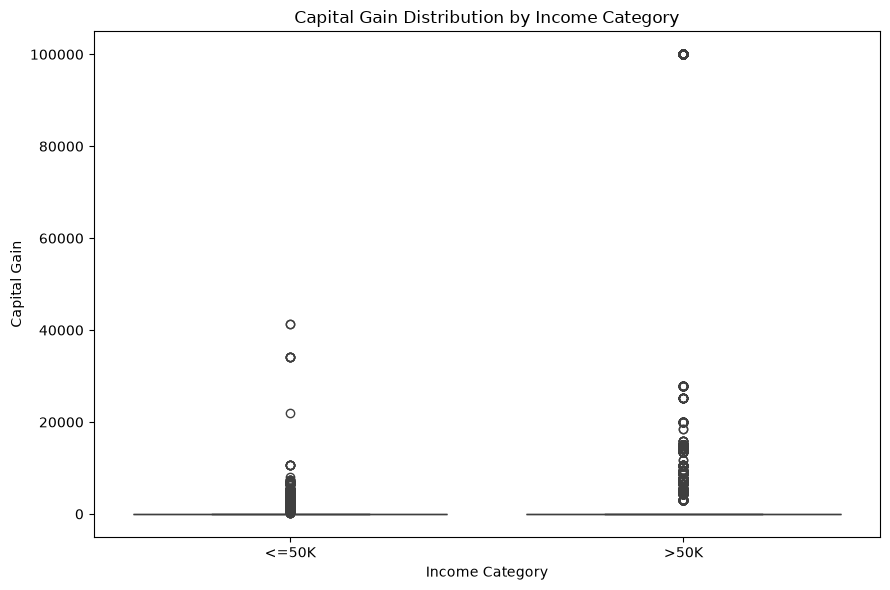

Capital Gain vs Income graph saved successfully!


In [23]:
# Capital Gain vs Income Visualization

plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df,
    x="income",
    y="capital-gain"
)

plt.title("Capital Gain Distribution by Income Category")
plt.xlabel("Income Category")
plt.ylabel("Capital Gain")

plt.tight_layout()

output_dir = Path("../screenshots/week2")
output_dir.mkdir(parents=True, exist_ok=True)

plt.savefig(
    output_dir / "capital_gain_vs_income.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Capital Gain vs Income graph saved successfully!")

## Capital Gain and Income Relationship

Capital gain shows a noticeable difference between the two income groups.

The average capital gain for individuals earning <=50K is 148.88, while the average for individuals earning >50K is 4007.16. The median is 0 for both groups, which indicates that most individuals in the dataset have no recorded capital gain.

The large difference in the mean values is therefore influenced by a relatively small number of individuals with substantial capital gains. This also explains why the distribution is highly skewed.

The result suggests that capital gain can be an informative feature when studying income, but the mean alone does not represent the typical individual because most observations have a value of zero.

In [28]:
# Step 47A: Correlation Analysis

numerical_cols = [
    "age",
    "fnlwgt",
    "education-num",
    "capital-gain",
    "capital-loss",
    "hours-per-week"
]

correlation_matrix = df[numerical_cols].corr().round(2)

correlation_matrix

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
age,1.00,-0.08,0.04,0.08,0.06,0.07
fnlwgt,-0.08,1.00,-0.04,0.00,-0.01,-0.02
education-num,0.04,-0.04,1.00,0.12,0.08,0.15
capital-gain,0.08,0.00,0.12,1.00,-0.03,0.08
capital-loss,0.06,-0.01,0.08,-0.03,1.00,0.05
hours-per-week,0.07,-0.02,0.15,0.08,0.05,1.00


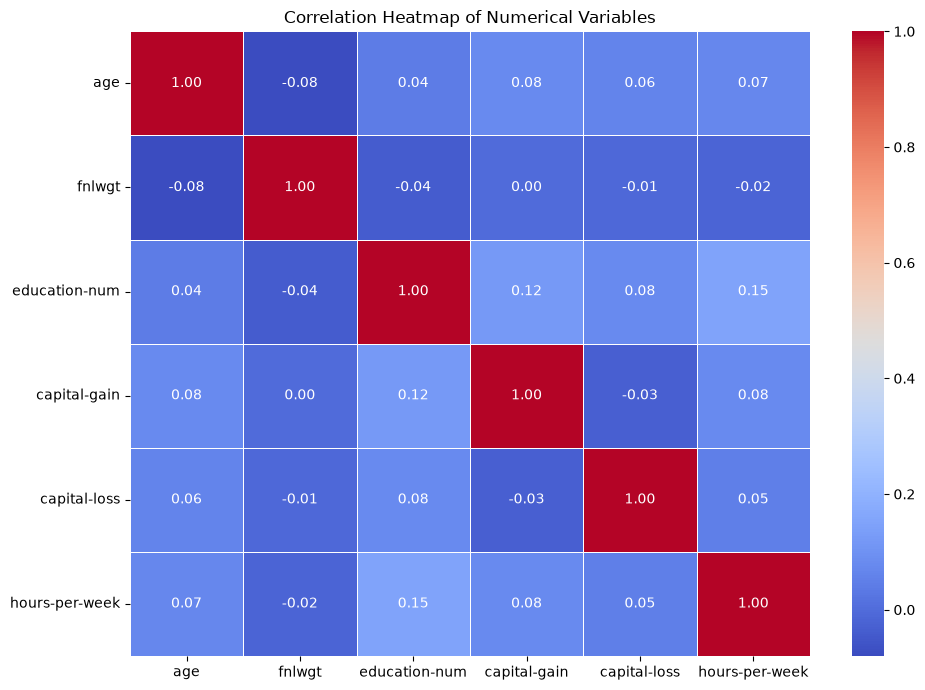

Correlation heatmap saved successfully!


In [29]:
# Correlation Heatmap

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numerical Variables")
plt.tight_layout()

output_dir = Path("../screenshots/week2")
output_dir.mkdir(parents=True, exist_ok=True)

plt.savefig(
    output_dir / "correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Correlation heatmap saved successfully!")

## Correlation Analysis

The correlation heatmap shows the relationships between the numerical variables in the dataset.

Among the numerical variables, education-num and hours-per-week have a positive correlation of approximately 0.15. Education-num also has a small positive relationship with capital-gain.

Age has relatively weak correlations with most numerical variables, although it shows a positive relationship with capital-gain and hours-per-week.

The strongest relationships with the binary income variable were observed for education-num (0.335), age (0.234), hours-per-week (0.230), and capital-gain (0.223).

Overall, the correlations are mostly weak to moderate, indicating that income differences are likely influenced by multiple variables rather than one numerical feature alone.

In [30]:
# Step 48: Capital Loss vs Income Analysis

capital_loss_income = df.groupby("income")["capital-loss"].agg(
    ["count", "mean", "median", "min", "max"]
).round(2)

capital_loss_income

,count,mean,median,min,max
income,,,,,
<=50K,24698,53.19,0.0,0,4356
>50K,7839,195.05,0.0,0,3683


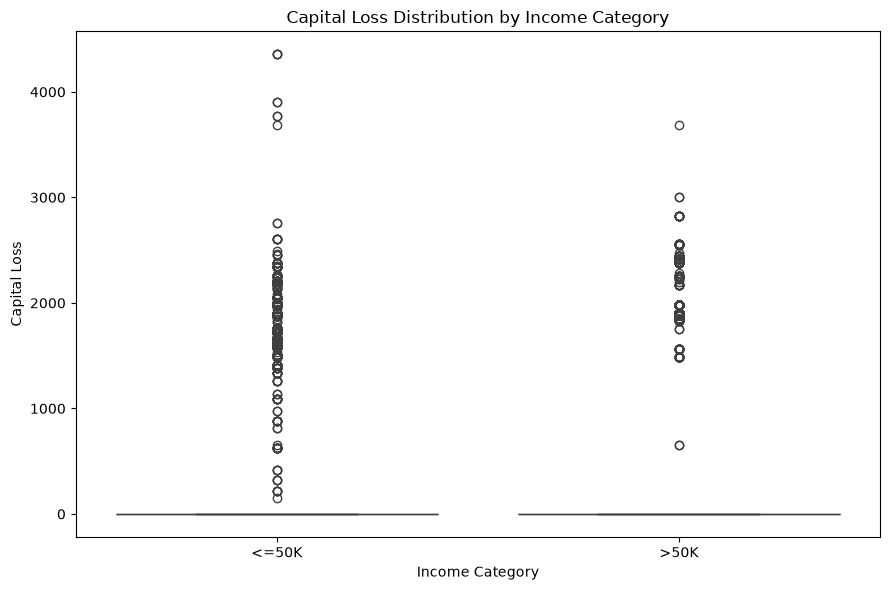

Capital Loss vs Income graph saved successfully!


In [31]:
# Capital Loss vs Income Visualization

plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df,
    x="income",
    y="capital-loss"
)

plt.title("Capital Loss Distribution by Income Category")
plt.xlabel("Income Category")
plt.ylabel("Capital Loss")

plt.tight_layout()

output_dir = Path("../screenshots/week2")
output_dir.mkdir(parents=True, exist_ok=True)

plt.savefig(
    output_dir / "capital_loss_vs_income.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Capital Loss vs Income graph saved successfully!")

## Capital Loss and Income Relationship

Capital loss is highly concentrated around zero in the dataset, with most individuals having no recorded capital loss.

The distribution shows that individuals earning >50K have a higher average capital loss compared with individuals earning <=50K. However, the median capital loss for both groups is zero.

This indicates that the difference in average values is influenced by a relatively small number of observations with non-zero capital losses.

Therefore, capital loss may provide useful information for understanding income differences, but its highly skewed distribution should be considered when using it in future machine-learning models.

In [32]:
# Step 49: Outlier Analysis for Hours per Week

Q1 = df["hours-per-week"].quantile(0.25)
Q3 = df["hours-per-week"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

hours_outliers = df[
    (df["hours-per-week"] < lower_bound) |
    (df["hours-per-week"] > upper_bound)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)
print("Number of outliers:", len(hours_outliers))
print("Outlier percentage:", round(len(hours_outliers) / len(df) * 100, 2), "%")

Q1: 40.0
Q3: 45.0
IQR: 5.0
Lower bound: 32.5
Upper bound: 52.5
Number of outliers: 9002
Outlier percentage: 27.67 %


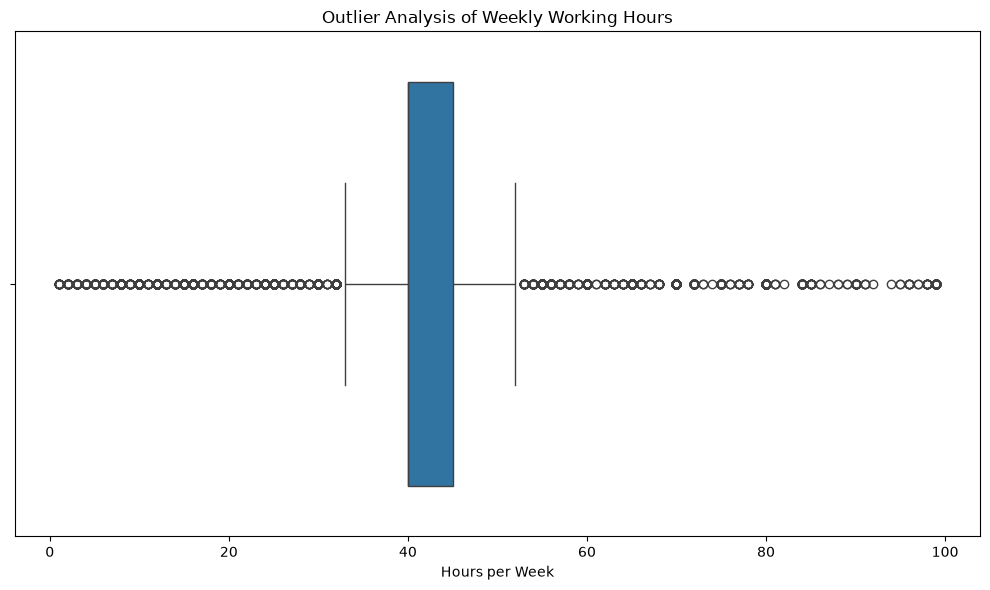

Hours per Week outlier graph saved successfully!


In [33]:
# Hours per Week Outlier Visualization

plt.figure(figsize=(10, 6))

sns.boxplot(
    x=df["hours-per-week"]
)

plt.title("Outlier Analysis of Weekly Working Hours")
plt.xlabel("Hours per Week")

plt.tight_layout()

output_dir = Path("../screenshots/week2")
output_dir.mkdir(parents=True, exist_ok=True)

plt.savefig(
    output_dir / "hours_per_week_outliers.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Hours per Week outlier graph saved successfully!")

## Outlier Analysis of Weekly Working Hours

The IQR method identifies observations outside the range of 32.5 to 52.5 hours per week as statistical outliers.

Approximately 27.67% of the observations fall outside this range. This relatively high percentage suggests that the IQR rule is identifying many legitimate working-hour patterns rather than necessarily indicating data-entry errors.

For example, individuals may naturally work fewer than 32.5 hours or substantially more than 52.5 hours per week.

Therefore, these observations should not be automatically removed. The outlier analysis is used to understand the distribution and identify values that may require further investigation before any future machine-learning preprocessing.

# Step 50: Key Findings from Exploratory Data Analysis

## Key Findings

### 1. Income Distribution

The dataset contains 32,537 individuals. Approximately 75.91% belong to the <=50K income category, while 24.09% belong to the >50K category.

This shows that the target variable is imbalanced, with substantially more observations in the <=50K category.

### 2. Age and Income

Age shows a positive relationship with income. The proportion of individuals earning >50K generally increases from the younger age groups and reaches its highest level among the 46-55 age group before decreasing in the older groups.

This suggests that age may be a useful feature for future income prediction.

### 3. Education and Income

Education shows one of the clearest relationships with income.

Higher education levels generally have a greater proportion of individuals earning >50K. For example, the >50K proportion is substantially higher among individuals with Master's, Doctorate, and Professional School education compared with lower education categories.

### 4. Occupation and Income

Income distribution varies considerably across occupations.

Exec-managerial and Prof-specialty occupations have relatively high proportions of individuals earning >50K, while occupations such as Other-service and Priv-house-serv have much lower proportions.

This indicates that occupation is likely to be an informative feature for income prediction.

### 5. Workclass and Income

Self-emp-inc and Federal-gov show relatively higher proportions of >50K income compared with several other workclass categories.

However, categories containing unknown values represented by `?` should be handled carefully in future modelling.

### 6. Working Hours and Income

Individuals earning >50K generally work more hours per week than those earning <=50K.

The correlation between hours-per-week and the binary income variable is approximately 0.230, indicating a positive but moderate relationship.

### 7. Capital Gain and Capital Loss

Capital gain shows a large difference between the two income groups. The mean capital gain is considerably higher for individuals earning >50K.

However, both capital gain and capital loss are highly skewed because most observations have a value of zero.

### 8. Numerical Correlations

Education-num has the strongest numerical correlation with the binary income variable at approximately 0.335.

Age, hours-per-week, and capital-gain also show positive relationships with income.

The relatively weak correlations between most individual numerical variables suggest that income is influenced by multiple factors rather than a single numerical feature.

### 9. Outliers

The IQR method identified a relatively large number of statistical outliers, particularly in hours-per-week.

These observations were not automatically removed because many may represent legitimate working patterns rather than data errors.

## Overall Conclusion

The exploratory analysis shows that income is associated with several demographic, educational, occupational, and financial characteristics.

Education, occupation, age, working hours, capital gain, workclass, and marital status all show useful patterns in relation to income.

The analysis also identified class imbalance, skewed financial variables, and statistical outliers that should be considered during future machine-learning development.

These findings provide a foundation for feature engineering, encoding, and model development in the next stage of the project.

# Week 2 EDA Completion

The exploratory data analysis for the cleaned Adult Income dataset has been completed.

The analysis covered:

- Dataset structure and summary statistics
- Income distribution
- Age distribution and age-group analysis
- Education and income relationship
- Workclass and income relationship
- Occupation and income relationship
- Marital status and income relationship
- Sex and income relationship
- Working hours and income relationship
- Capital gain and capital loss analysis
- Numerical correlation analysis
- Outlier analysis
- Key findings and observations

The results from this analysis will be used to guide feature engineering and machine-learning preparation in the following stage of the project.